# Project Work XAI

In [1]:
import torch

device_try = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device_try}")

Selected device: cuda


In [2]:
import os

print("=== TEST TMUX ===")
tmux_var = os.environ.get("TMUX")

if tmux_var:
    print("STATUS: Jupyter server is running in a TMUX session!")
    print(f"Tmux socket path: {tmux_var}")
else:
    print("STATUS: The Jupyter server is NOT inside Tmux.")

=== TEST TMUX ===
STATUS: Jupyter server is running in a TMUX session!
Tmux socket path: /tmp/tmux-1022/default,126489,1


## Environment management

In [3]:
from k_validation.K_fold import *
from models.neural_network import *
from utils.data_processing import *
from utils.pipeline import pipeline

## Data extraction
In order to assess the importance of Solar Flux variable for predictions, in this evaluation such variable will be kept in the dataset and model performance will be evaluated considering data obtained in this way.

In [4]:
X, y, feature_names = load_and_preprocess_data(dataset_path="../Data/MARSIS_historical_dataset.csv", orbit_path="../Data/orbit_to_remove", keep_flux=True)

## Creating Data Splits and Training

### Experiment 1: batch_size = 32

In [ ]:
k_fold_dict_1, save_dir_1 = pipeline(X, y, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=32, exp_name="exp_1")

=== Starting Experiment Pipeline: exp_1 ===
Created isolated environment at: experiments/exp_1_20260725_113507

--- Starting FOLD 0 ---


Early stopping at epoch 19
Train MSE: 7.860, Test MSE: 11.731, Train MAE: 2.142, Test MAE: 2.641

--- Starting FOLD 1 ---


Early stopping at epoch 13
Train MSE: 8.123, Test MSE: 10.165, Train MAE: 2.205, Test MAE: 2.516

--- Starting FOLD 2 ---


Early stopping at epoch 11
Train MSE: 8.554, Test MSE: 10.347, Train MAE: 2.278, Test MAE: 2.582

--- Starting FOLD 3 ---


Early stopping at epoch 11
Train MSE: 8.699, Test MSE: 11.953, Train MAE: 2.294, Test MAE: 2.703

--- Starting FOLD 4 ---


Early stopping at epoch 12
Train MSE: 7.521, Test MSE: 26.203, Train MAE: 2.087, Test MAE: 3.872

--- Starting FOLD 5 ---


Early stopping at epoch 11
Train MSE: 8.283, Test MSE: 47.688, Train MAE: 2.242, Test MAE: 5.143

--- Starting FOLD 6 ---


Training:   2%|███▏                                                                                                                                                                           | 18/1000 [27:36<25:15:54, 92.62s/it, Train MSE=8.7700, Val MSE=15.1194]

### Experiment 2: batch_size = 256

=== Starting Experiment Pipeline: exp_2 ===
Created isolated environment at: experiments/exp_2_20260521_203007

--- Starting FOLD 0 ---


Early stopping at epoch 19
Train MSE: 7.700, Test MSE: 11.421, Train MAE: 2.147, Test MAE: 2.630

--- Starting FOLD 1 ---


Early stopping at epoch 15
Train MSE: 7.599, Test MSE: 10.075, Train MAE: 2.116, Test MAE: 2.494

--- Starting FOLD 2 ---


Early stopping at epoch 18
Train MSE: 7.033, Test MSE: 11.089, Train MAE: 2.024, Test MAE: 2.638

--- Starting FOLD 3 ---


Early stopping at epoch 14
Train MSE: 8.173, Test MSE: 12.840, Train MAE: 2.200, Test MAE: 2.748

--- Starting FOLD 4 ---


...

Early stopping at epoch 13
Train MSE: 7.752, Test MSE: 47.549, Train MAE: 2.115, Test MAE: 5.218

--- Starting FOLD 6 ---


Early stopping at epoch 15
Train MSE: 7.693, Test MSE: 36.319, Train MAE: 2.136, Test MAE: 4.439

--- Starting FOLD 7 ---


Early stopping at epoch 17
Train MSE: 7.459, Test MSE: 21.738, Train MAE: 2.115, Test MAE: 3.576

--- Starting FOLD 8 ---


Early stopping at epoch 15
Train MSE: 8.762, Test MSE: 13.136, Train MAE: 2.345, Test MAE: 3.011

--- Starting FOLD 9 ---


Early stopping at epoch 12
Train MSE: 7.973, Test MSE: 11.121, Train MAE: 2.133, Test MAE: 2.457

Execution 'exp_2' successfully completed in 2734.59s!
Generating Learning Curves...


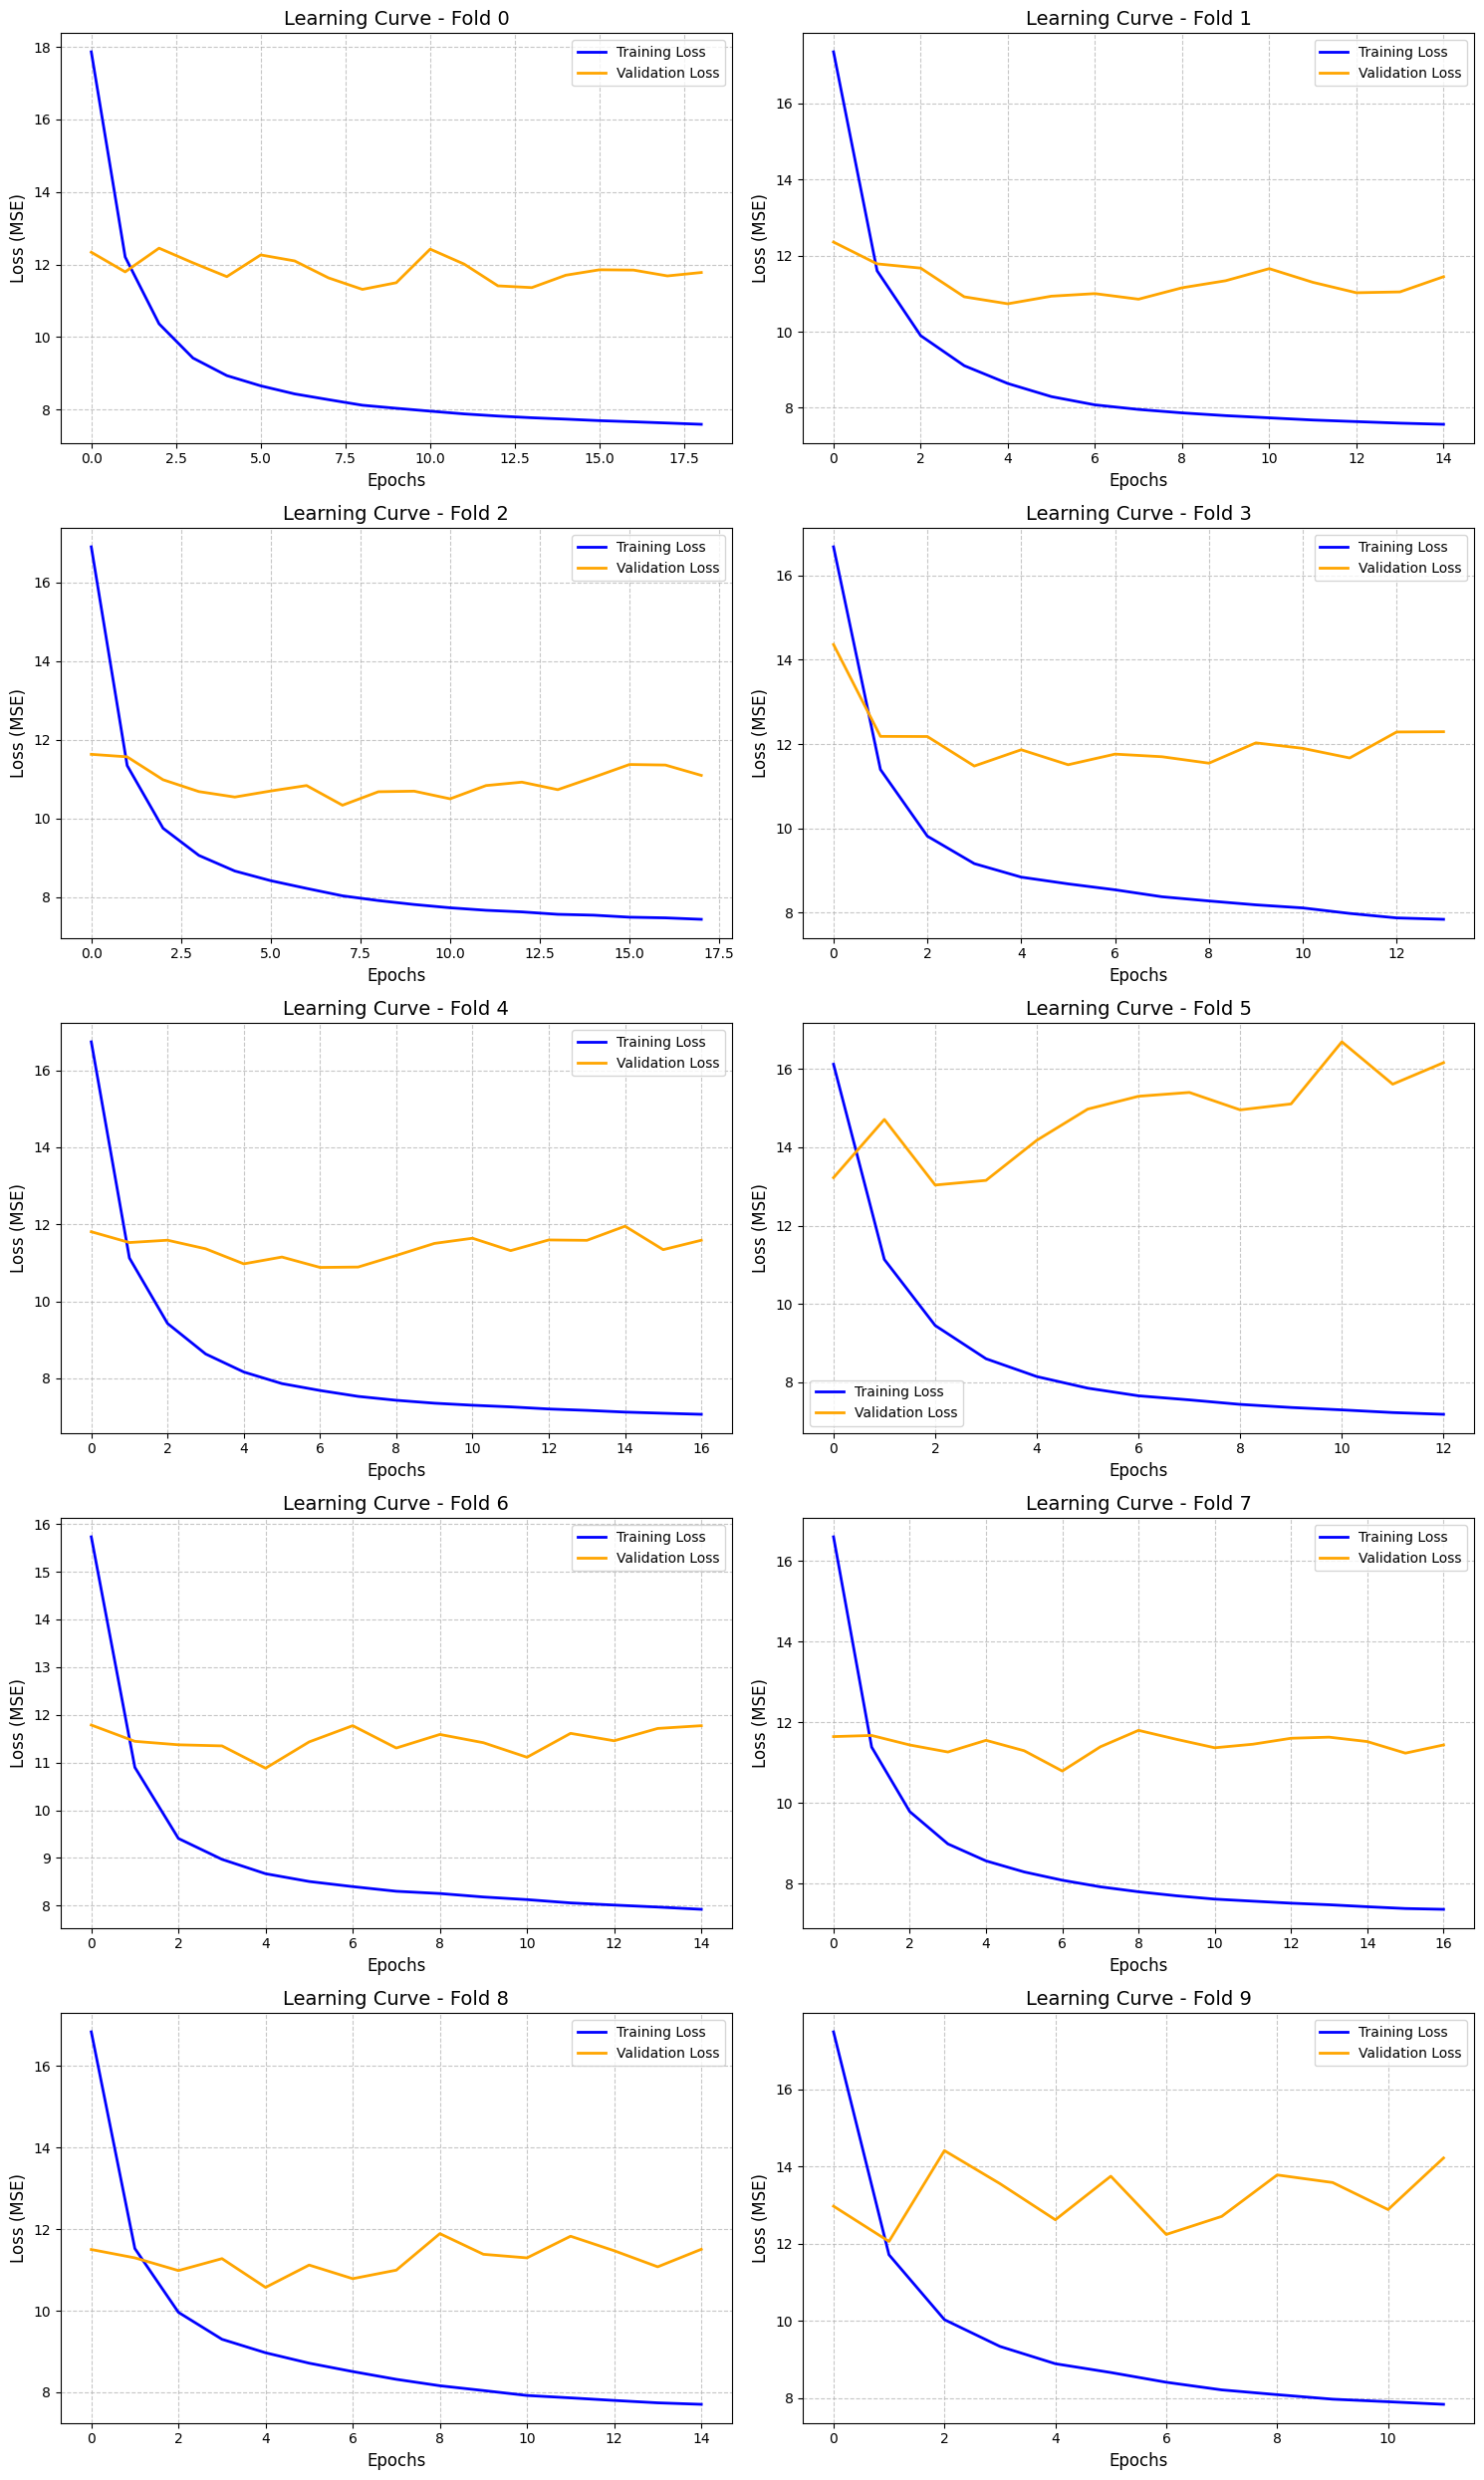

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/experiments/exp_2_20260521_203007


In [12]:
k_fold_dict_2, save_dir_2 = pipeline(X, y, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=256, exp_name="exp_2")

In [12]:
print(k_fold_dict_2)

{'MAE': 3.370018347040911, 'MAPE': 0.25563652946529525, 'MSE': 21.30989163630756, 'predictions': array([12.59172058, 12.59132671, 12.59096813, ..., 11.67141724,
       11.66817188, 11.66492653], shape=(1905841,)), 'execution_time': 1914.3073630332947, 'histories': [{'train_loss': [np.float64(19.6568941647013), np.float64(12.013114592464108), np.float64(9.942472551181687), np.float64(8.96185637540316), np.float64(8.470467870734735), np.float64(8.195428006231163), np.float64(8.027416511033428), np.float64(7.923415067322), np.float64(7.843182303185606), np.float64(7.7853362569364615), np.float64(7.726424845311401)], 'val_loss': [12.658727645874023, 16.161497116088867, 14.178004264831543, 14.40145492553711, 14.3273344039917, 13.14233684539795, 13.764396667480469, 12.981348991394043, 13.274319648742676, 14.384540557861328, 14.998696327209473]}, {'train_loss': [np.float64(19.05168944048735), np.float64(11.796182740922593), np.float64(9.821664746691983), np.float64(8.822877163081358), np.floa

### Experiment 3: batch_size = 32 no flux

In [ ]:
X_3, y_3, feature_names_3 = load_and_preprocess_data(dataset_path="../Data/MARSIS_historical_dataset.csv", orbit_path="../Data/orbit_to_remove", keep_flux=False)

=== Starting Experiment Pipeline: exp_3 ===
Created isolated environment at: experiments/exp_3_20260520_195537

--- Starting FOLD 0 ---


Early stopping at epoch 15
Train MSE: 7.846, Test MSE: 13.905, Train MAE: 2.142, Test MAE: 2.798

--- Starting FOLD 1 ---


Early stopping at epoch 18
Train MSE: 7.556, Test MSE: 9.821, Train MAE: 2.080, Test MAE: 2.439

--- Starting FOLD 2 ---


Early stopping at epoch 19
Train MSE: 7.426, Test MSE: 11.135, Train MAE: 2.055, Test MAE: 2.652

--- Starting FOLD 3 ---


Early stopping at epoch 14
Train MSE: 7.656, Test MSE: 14.076, Train MAE: 2.082, Test MAE: 2.848

--- Starting FOLD 4 ---


...

Early stopping at epoch 14
Train MSE: 7.426, Test MSE: 46.958, Train MAE: 2.077, Test MAE: 4.990

--- Starting FOLD 6 ---


Early stopping at epoch 17
Train MSE: 7.582, Test MSE: 37.165, Train MAE: 2.100, Test MAE: 4.415

--- Starting FOLD 7 ---


Early stopping at epoch 11
Train MSE: 8.635, Test MSE: 19.927, Train MAE: 2.283, Test MAE: 3.361

--- Starting FOLD 8 ---


Early stopping at epoch 11
Train MSE: 9.230, Test MSE: 25.673, Train MAE: 2.392, Test MAE: 3.725

--- Starting FOLD 9 ---


Early stopping at epoch 17
Train MSE: 7.840, Test MSE: 13.368, Train MAE: 2.117, Test MAE: 2.707

Execution 'exp_3' successfully completed in 13315.90s!
Generating Learning Curves...


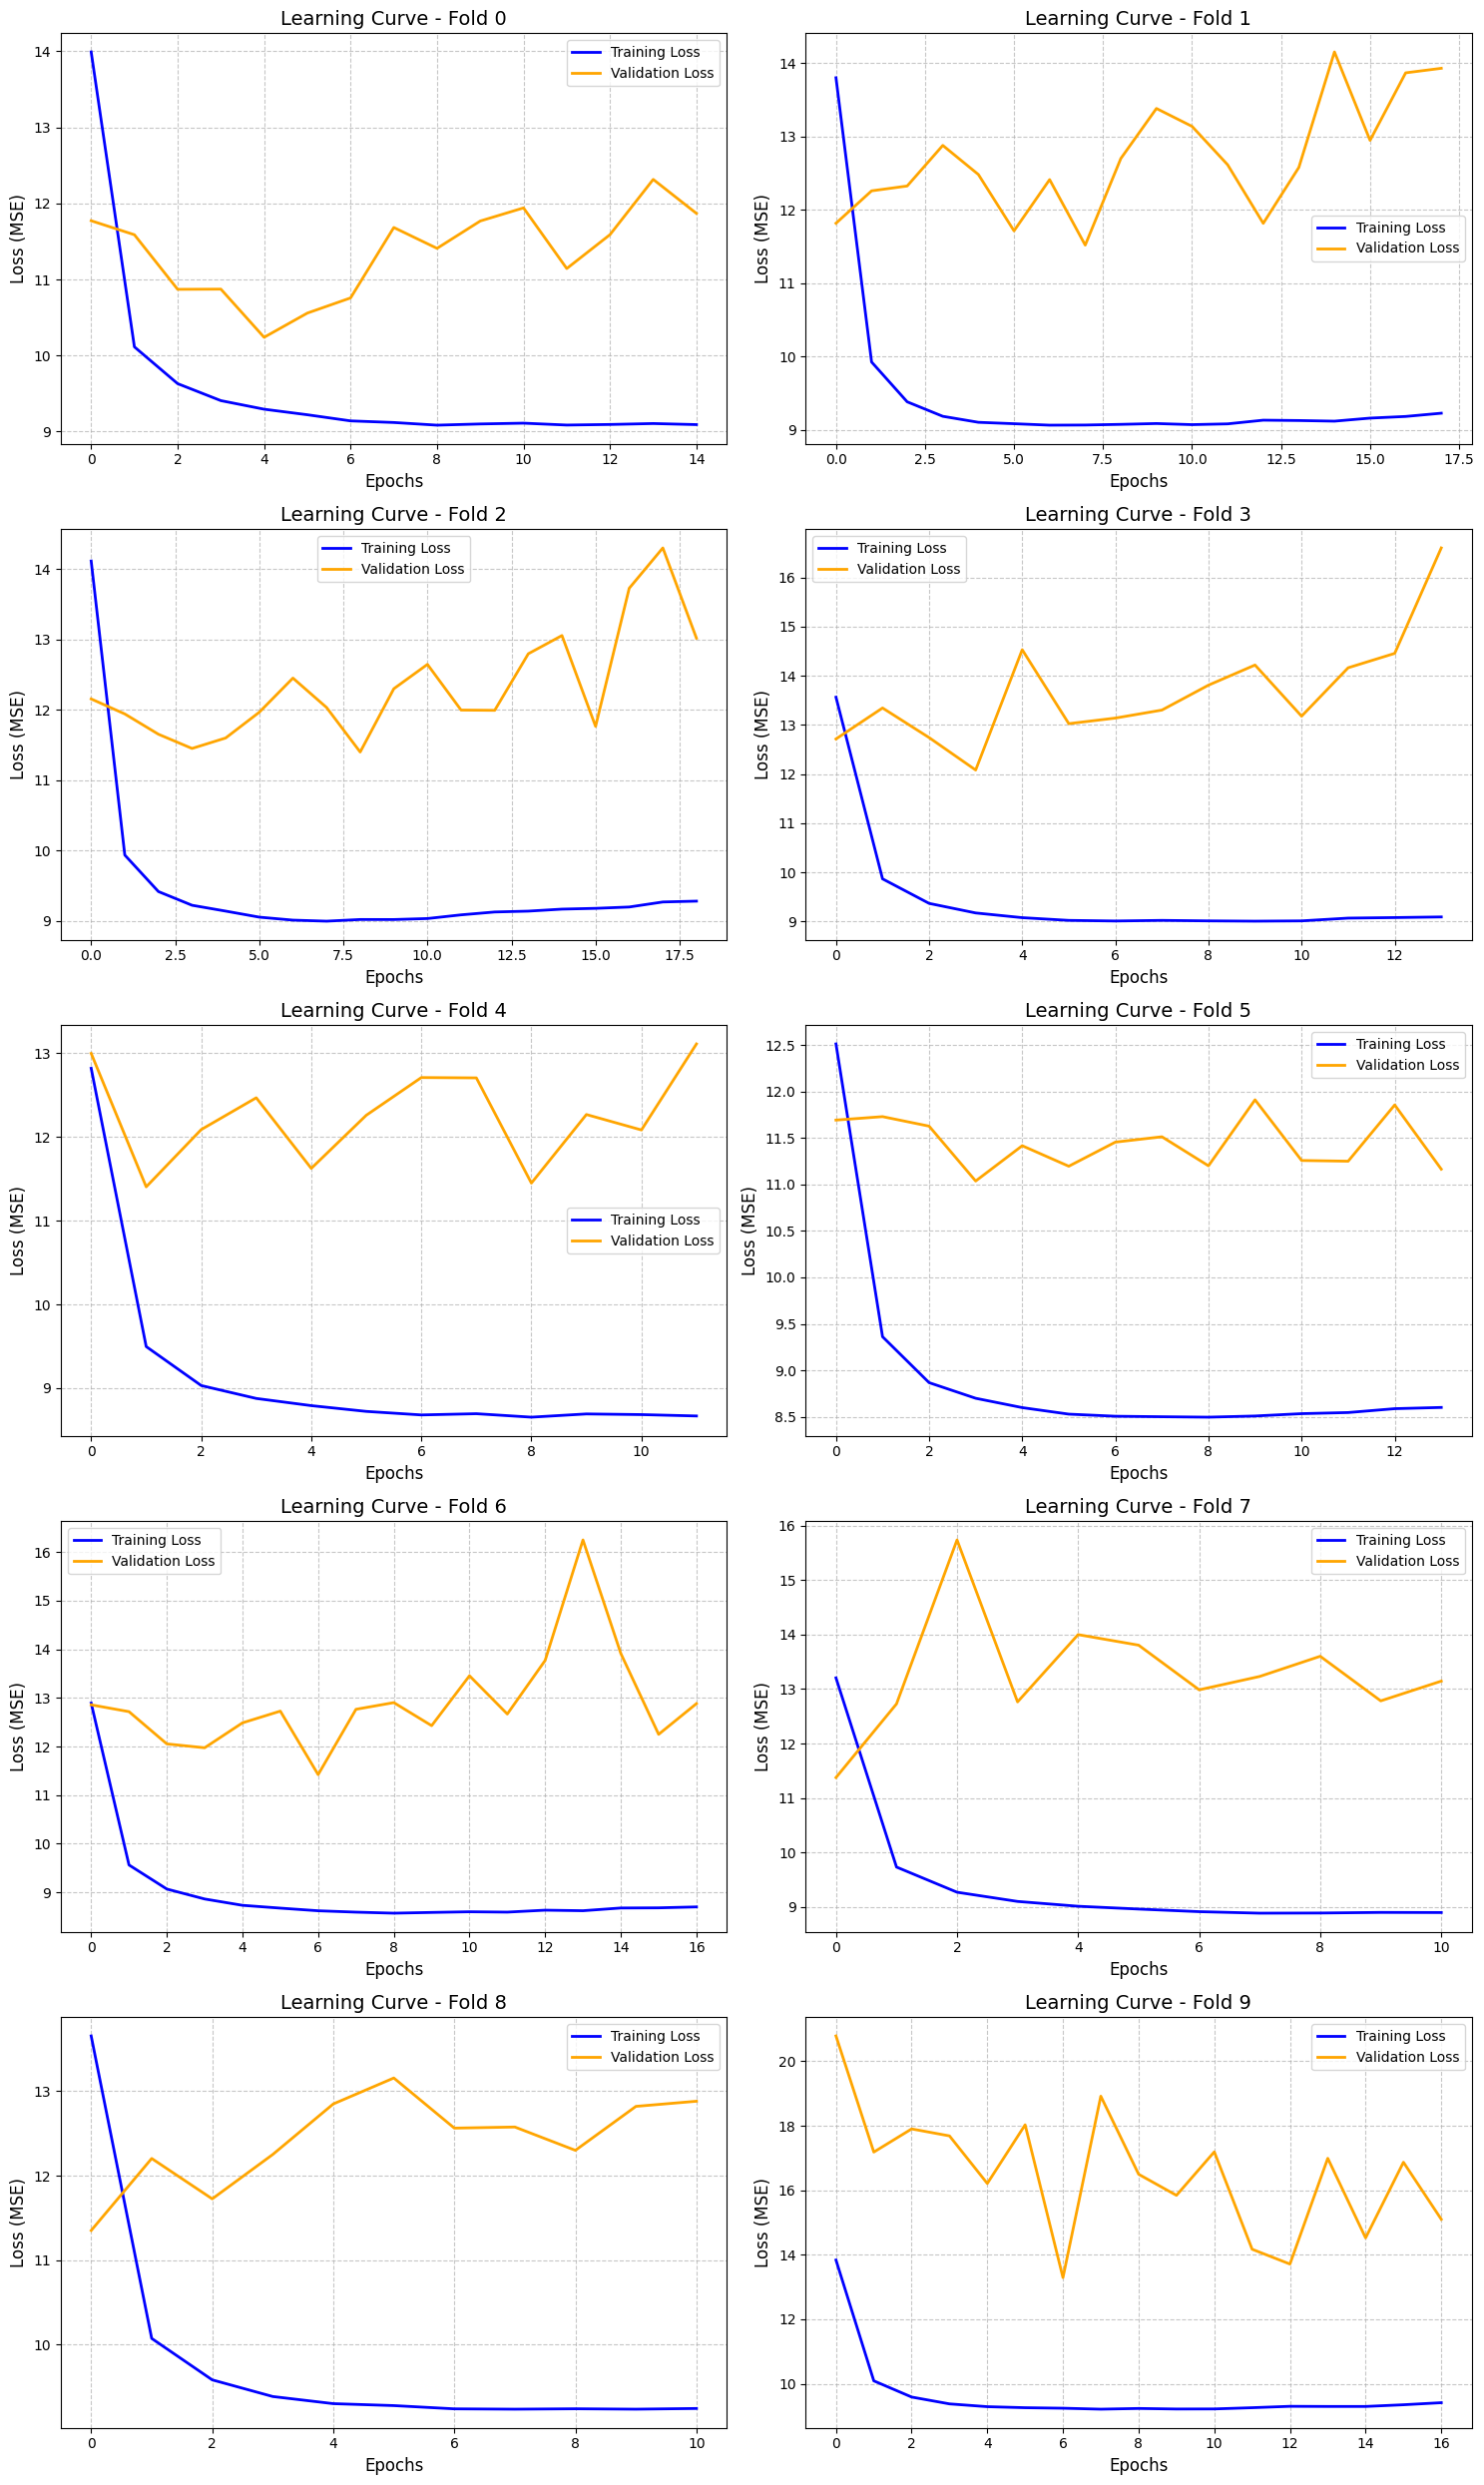

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/experiments/exp_3_20260520_195537


In [12]:
k_fold_dict_3, save_dir_3 = pipeline(X_3, y_3, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=32, exp_name="exp_3")

### Comparison between corresponding tensorflow and pytorch outputs

=== Starting Experiment Comparison Analysis ===
Analisi exp tensorflow...
-> Rilevato formato TensorFlow. Estratti 10 valori MAE.
Analisi exp pytorch...
-> Rilevato formato PyTorch. Estratti 10 valori MAE.


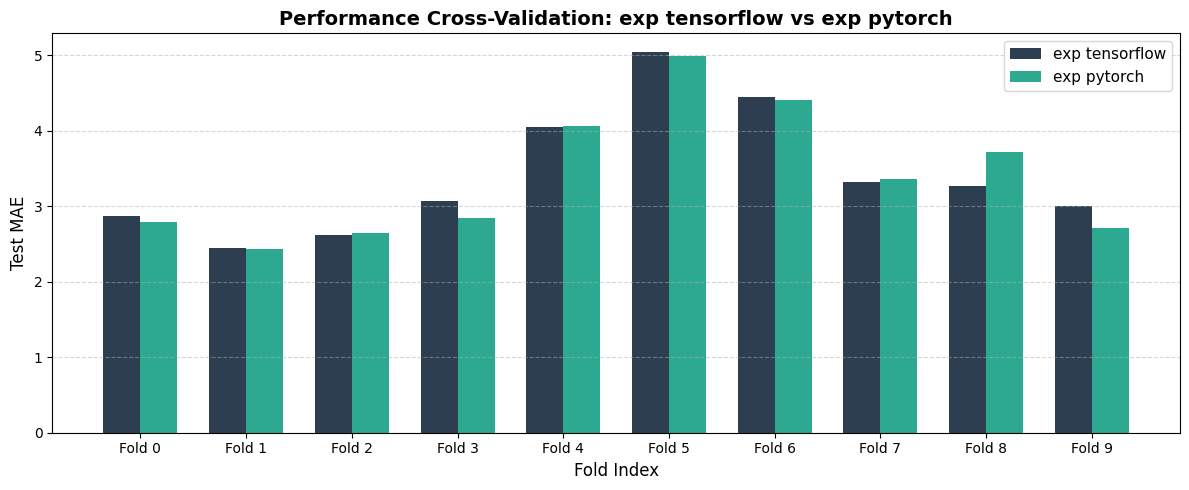

📊 Grafici salvati in:
   - ./comparison_20260523_exp_tensorflow_vs_exp_pytorch.png
   - ./comparison_20260523_exp_tensorflow_vs_exp_pytorch.pdf
=== Processo di Confronto Completato ===


In [ ]:
# TODO: inserire i parametri corretti in questa funzione una volta che il training è terminato
compare_experiments_pipeline(
    "2026_05_17_23_49_OUTPUTS_ORIGINAL_KERAS_ALL.txt", 
    "experiments/exp_3_20260520_195537/MAE_exp_3.txt", 
    exp1_label="exp tensorflow",
    exp2_label="exp pytorch",
    output_dir=".", 
    show_plots=True
)

### Comparison between Exp 1 (with flux) and Exp 3 (no flux)

=== Starting Experiment Comparison Analysis ===
Analisi exp 1 (flux)...
-> Rilevato formato PyTorch. Estratti 10 valori MAE.
Analisi exp 2 (no flux)...
-> Rilevato formato PyTorch. Estratti 10 valori MAE.


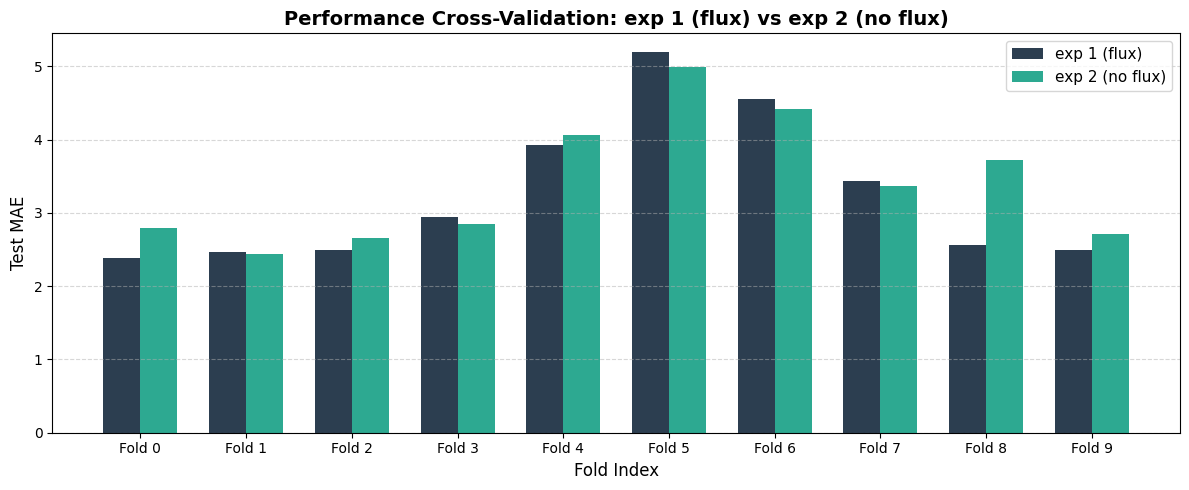

📊 Grafici salvati in:
   - ./comparison_20260523_exp_1_(flux)_vs_exp_2_(no_flux).png
   - ./comparison_20260523_exp_1_(flux)_vs_exp_2_(no_flux).pdf
=== Processo di Confronto Completato ===


In [ ]:
# TODO: inserire i parametri corretti in questa funzione una volta che il training è terminato

compare_experiments_pipeline(
    "experiments/exp_1_20260521_160615/MAE_exp_1.txt", 
    "experiments/exp_3_20260520_195537/MAE_exp_3.txt", 
    exp1_label="exp 1 (flux)",
    exp2_label="exp 2 (no flux)",
    output_dir=".", 
    show_plots=True
)

Caricamento in corso dei dizionari dei risultati...
✅ Plot 1 salvato: comparison_plots/bar_chart_mse_20260523_164432 (.png e .pdf)


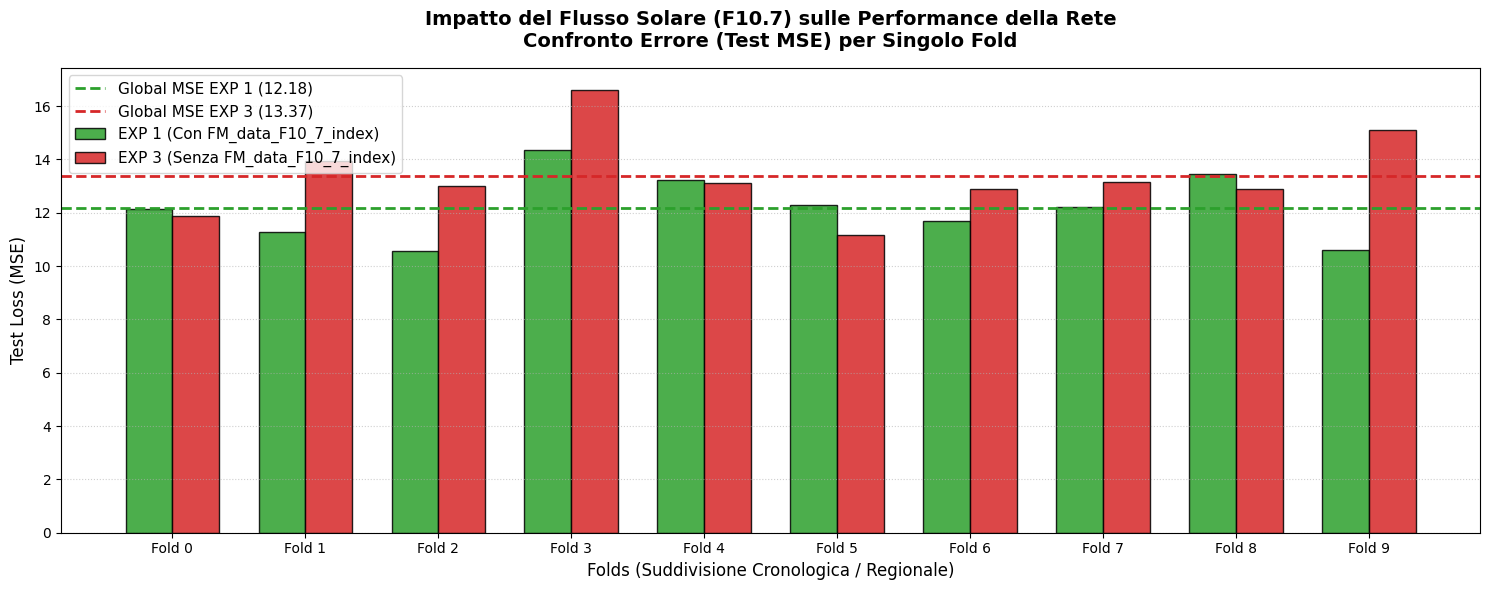

✅ Plot 2 salvato: comparison_plots/learning_curve_fold_8_20260523_164432 (.png e .pdf)


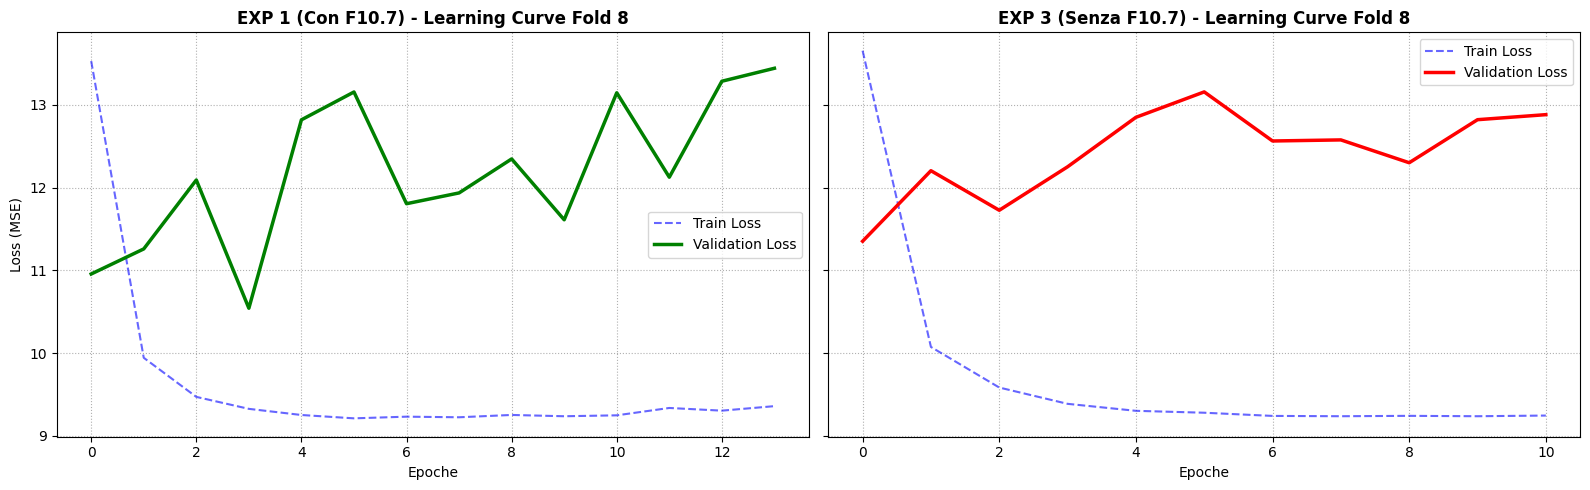

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

os.makedirs("comparison_plots", exist_ok=True)
timestamp_plots = datetime.now().strftime("%Y%m%d_%H%M%S")

# =====================================================================
# defining paths TODO: aggiornare con i nuovi paths
# =====================================================================
path_exp1 = "experiments/exp_1_20260521_160615/results_dict.pkl" # with solar flux
path_exp3 = "experiments/exp_3_20260520_195537/results_dict.pkl" # without solar flux

# loading results
print("Loading result dictionaries...")
with open(path_exp1, "rb") as f:
    dict_exp1 = pickle.load(f)

with open(path_exp3, "rb") as f:
    dict_exp3 = pickle.load(f)

# Automatic extraction of MSE values ​​from 'histories'
# Since the final `val_loss` value corresponds to the early stopping point (the fold's Test MSE)
mse_fold_exp1 = [h['val_loss'][-1] for h in dict_exp1['histories']]
mse_fold_exp3 = [h['val_loss'][-1] for h in dict_exp3['histories']]

# defining parameters for bar plot
num_folds = len(mse_fold_exp1)
folds = np.arange(num_folds)
width = 0.35  

# =====================================================================
# PLOT 1: COMPARATIVE BAR CHART - MSE TEST FOR FOLD
# =====================================================================
plt.figure(figsize=(15, 6))

# EXP 1 Bars (With Solar Flux)
plt.bar(folds - width/2, mse_fold_exp1, width, label='EXP 1 (with FM_data_F10_7_index)', 
        color='#2ca02c', alpha=0.85, edgecolor='black')

# EXP 3 Bars (Without Solar Flux)
plt.bar(folds + width/2, mse_fold_exp3, width, label='EXP 3 (without FM_data_F10_7_index)', 
        color='#d62728', alpha=0.85, edgecolor='black')

# Horizontal reference lines for the global mean error
global_mse_exp1 = np.mean(mse_fold_exp1)
global_mse_exp3 = np.mean(mse_fold_exp3)
plt.axhline(y=global_mse_exp1, color='#2ca02c', linestyle='--', linewidth=2, 
            label=f'Global MSE EXP 1 ({global_mse_exp1:.2f})')
plt.axhline(y=global_mse_exp3, color='#d62728', linestyle='--', linewidth=2, 
            label=f'Global MSE EXP 3 ({global_mse_exp3:.2f})')

plt.title("Impact of Solar Flux (F10.7) on Network Performance\nError Comparison (MSE Test) for Single Fold", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Folds (Chronological / Regional Breakdown)', fontsize=12)
plt.ylabel('Val Loss (MSE)', fontsize=12)
plt.xticks(folds, [f"Fold {i}" for i in folds], fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6, axis='y')
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()

# --- saving PLOT 1 ---
base_name_plot1 = f"comparison_plots/bar_chart_mse_{timestamp_plots}"
plt.savefig(f"{base_name_plot1}.png", dpi=600, bbox_inches='tight')
plt.savefig(f"{base_name_plot1}.pdf", format='pdf', bbox_inches='tight')
print(f" Plot 1 saved: {base_name_plot1} (.png and .pdf)")

plt.show()

# =====================================================================
# PLOT 2: FOCUS ON THE CRITICAL FOLD (FOLD 8) - LEARNING CURVES
# =====================================================================
# Fold 8 shows the most significant impact in logs. Checking training.
critical_fold = 8

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# EXP 1 Curves (With Solar Flux)
h1 = dict_exp1['histories'][critical_fold]
axes[0].plot(h1['train_loss'], label='Train Loss', color='blue', alpha=0.6, linestyle='--')
axes[0].plot(h1['val_loss'], label='Validation Loss', color='green', linewidth=2.5)
axes[0].set_title(f"EXP 1 (with F10.7) - Learning Curve Fold {critical_fold}", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss (MSE)")
axes[0].grid(True, linestyle=':')
axes[0].legend()

# EXP 3 Curves (Without Solar Flux)
h3 = dict_exp3['histories'][critical_fold]
axes[1].plot(h3['train_loss'], label='Train Loss', color='blue', alpha=0.6, linestyle='--')
axes[1].plot(h3['val_loss'], label='Validation Loss', color='red', linewidth=2.5)
axes[1].set_title(f"EXP 3 (without F10.7) - Learning Curve Fold {critical_fold}", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epochs")
axes[1].grid(True, linestyle=':')
axes[1].legend()

plt.tight_layout()

# --- saving PLOT 2 ---
base_name_plot2 = f"comparison_plots/learning_curve_fold_{critical_fold}_{timestamp_plots}"
plt.savefig(f"{base_name_plot2}.png", dpi=600, bbox_inches='tight')
plt.savefig(f"{base_name_plot2}.pdf", format='pdf', bbox_inches='tight')
print(f" Plot 2 saved in: {base_name_plot2} (.png and .pdf)")

plt.show()


### Comparison between Exp 1 (batch_size = 32) and Exp 2 (batch_size = 256)

=== Starting Experiment Comparison Analysis ===
Analisi exp 1 (batch_size=32)...
-> Rilevato formato PyTorch. Estratti 10 valori MAE.
Analisi exp 2 (batch_size=256)...
-> Rilevato formato PyTorch. Estratti 10 valori MAE.


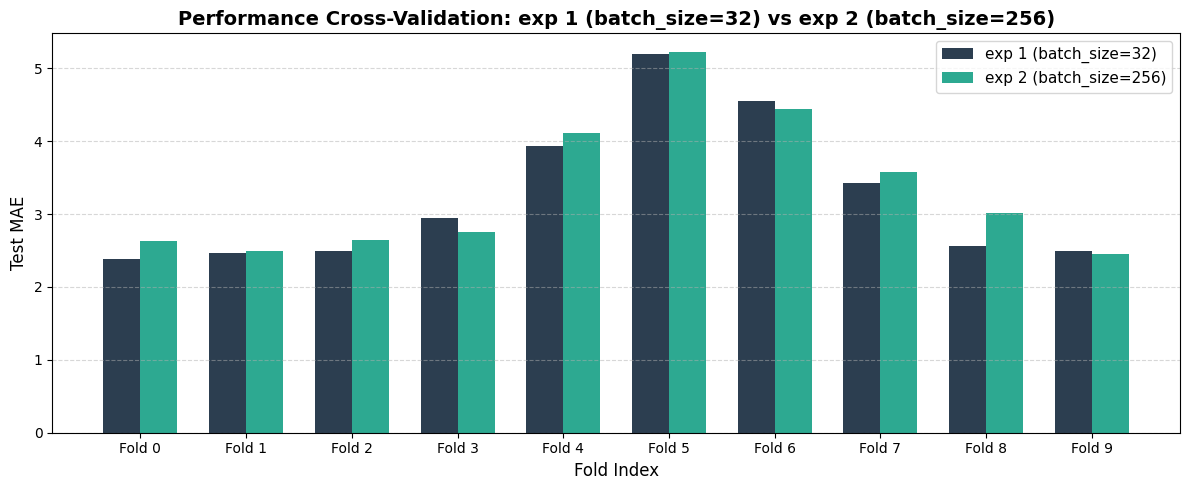

📊 Grafici salvati in:
   - ./comparison_20260523_exp_1_(batch_size=32)_vs_exp_2_(batch_size=256).png
   - ./comparison_20260523_exp_1_(batch_size=32)_vs_exp_2_(batch_size=256).pdf
=== Processo di Confronto Completato ===


In [ ]:
# TODO: inserire i parametri corretti in questa funzione una volta che il training è terminato

compare_experiments_pipeline(
    "experiments/exp_1_20260521_160615/MAE_exp_1.txt", 
    "experiments/exp_2_20260521_203007/MAE_exp_2.txt", 
    exp1_label="exp 1 (batch_size=32)",
    exp2_label="exp 2 (batch_size=256)",
    output_dir=".", 
    show_plots=True
)

## SHAP on Neural Network

### SHAP on experiment 2: Macro vs Micro Error Analysis

#### Data extraction using indices from previous pipeline k fold cross validation

In [ ]:
import re
import numpy as np
import os
from shap_utils.explain_with_shap import *

log_file_path = "experiments/exp_2_20260521_203007/MAE_exp_2.txt" # TODO: inserire il path corretto

# Dictionary for storing the reconstructed indices
extracted_test_indices = {}
fold_counter = 1

print(" Log reading and index reconstruction in progress...")

# reading from txt file
if os.path.exists(log_file_path):
    with open(log_file_path, 'r') as file:
        for line in file:
            # isolating the rows corresponding to the test set.
            if line.startswith("TEST:"):
                # re.findall(r'\d+', line) extracts all groups of numbers, ignoring parentheses and dots
                numbers = [int(n) for n in re.findall(r'\d+', line)]
                
                if len(numbers) >= 2:
                    start_idx = numbers[0]   # E.g. Fold 1: 190585
                    end_idx = numbers[-1]    # E.g. Fold 1: 381168
                    
                    # Generates the contiguous array: [190585, 190586, ..., 381168]
                    extracted_test_indices[fold_counter] = np.arange(start_idx, end_idx + 1)
                
                fold_counter += 1
else:
    raise FileNotFoundError(f"File non trovato al percorso: {log_file_path}")

# Global index-based allocation
total_samples = len(X)
all_indices = np.arange(total_samples)

# ==========================================
# DATA EXTRACTION - FOLD 1
# ==========================================
# The test set is the newly reconstructed array.
test_idx_f1 = extracted_test_indices[1]
# The training set consists of everything else (Global indices – Test indices).
train_idx_f1 = np.setdiff1d(all_indices, test_idx_f1) 

X_train_fold1 = X[train_idx_f1]
X_test_fold1  = X[test_idx_f1]

# ==========================================
# DATA EXTRACTION - FOLD 5 
# ==========================================
test_idx_f5 = extracted_test_indices[5]
train_idx_f5 = np.setdiff1d(all_indices, test_idx_f5)

X_train_fold5 = X[train_idx_f5]
X_test_fold5  = X[test_idx_f5]
# extracting also the actual targets to calculate the actual error on the waterfall charts.
y_test_fold5  = y[test_idx_f5]

print(" Operation completed successfully! The extracted data is:")
print(f"   - FOLD 1 -> Train: {X_train_fold1.shape}, Test: {X_test_fold1.shape}")
print(f"   - FOLD 5 -> Train: {X_train_fold5.shape}, Test: {X_test_fold5.shape}")

# SONO ARRIVATO QUI TODO: ricontrollare bene la gestione di indici e fold. dovrebbe essere sicuro che i fold sono ordinati in modo cronologico perché non è stato fatto lo shuffle ma verificare. ora l'indice sui fold 
# parte da 1 e non da 0

🔍 Lettura del log e ricostruzione degli indici in corso...
✅ Operazione completata con successo! I dati estratti sono:
   🔹 FOLD 1 -> Train: (1715257, 19), Test: (190584, 19)
   🔹 FOLD 5 -> Train: (1715257, 19), Test: (190584, 19)


In [13]:
# 0. Estrazione preliminare dei nomi delle feature (con Solar Flux incluso)
feature_names_2 = extract_feature_names(dataset_path="Data/MARSIS_historical_dataset.csv", keep_flux=True)
input_dim_2 = len(feature_names_2)

#### Fold 1 and Fold 5


--- 1A. Esecuzione SHAP su FOLD 1 (Zona Regolare - Performance Buone) ---

=== STARTING SHAP PIPELINE ===
Model: experiments/exp_2_20260521_203007/model_exp_2_1.pth | Scaler: experiments/exp_2_20260521_203007/scaler_chrono_exp_2_1.save
Forced device for SHAP stability: cpu
SHAP calculation (Background: 500 samples, Test: 2000 samples)...
Generating plot...
SHAP calculation completed.

--- 1B. Esecuzione SHAP su FOLD 5 (Zona Problematica - Errore Elevato) ---

=== STARTING SHAP PIPELINE ===
Model: experiments/exp_2_20260521_203007/model_exp_2_5.pth | Scaler: experiments/exp_2_20260521_203007/scaler_chrono_exp_2_5.save
Forced device for SHAP stability: cpu
SHAP calculation (Background: 500 samples, Test: 2000 samples)...
Generating plot...
SHAP calculation completed.



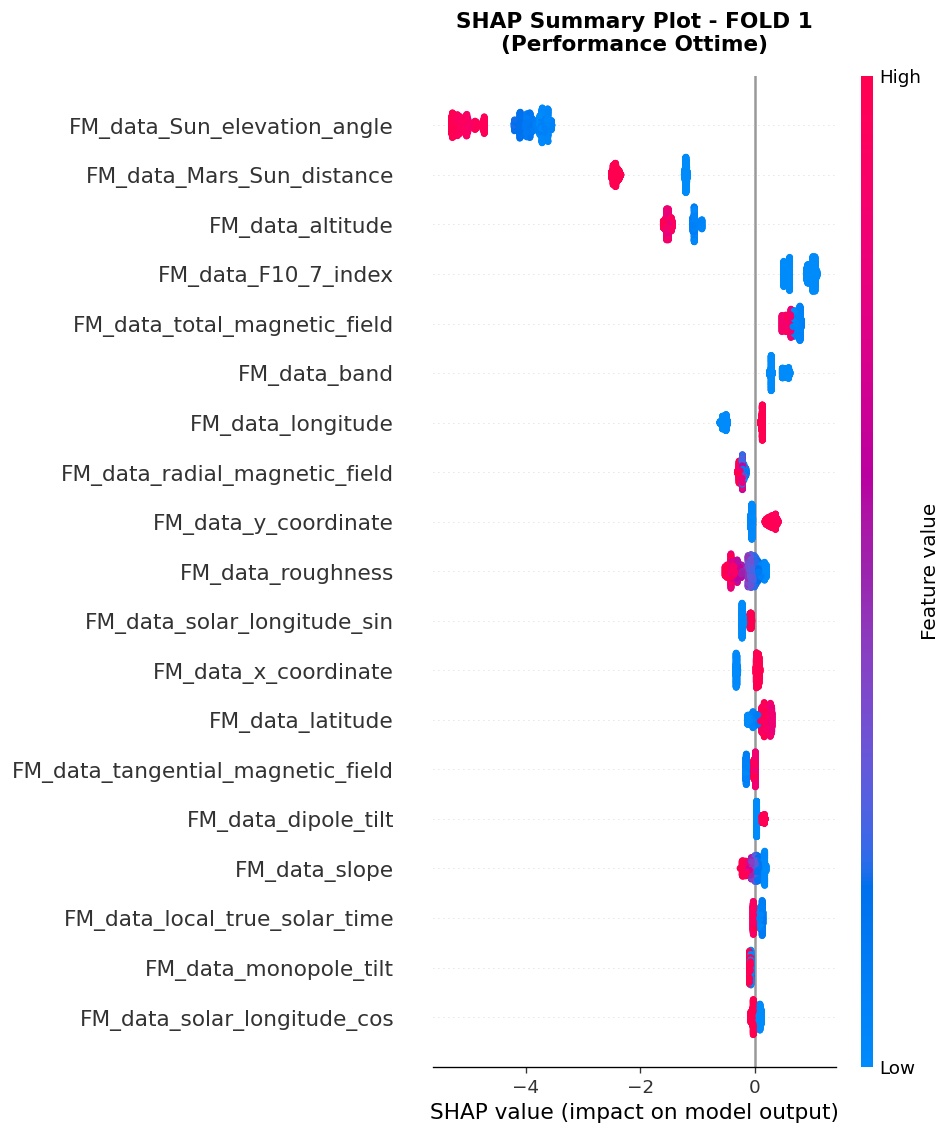
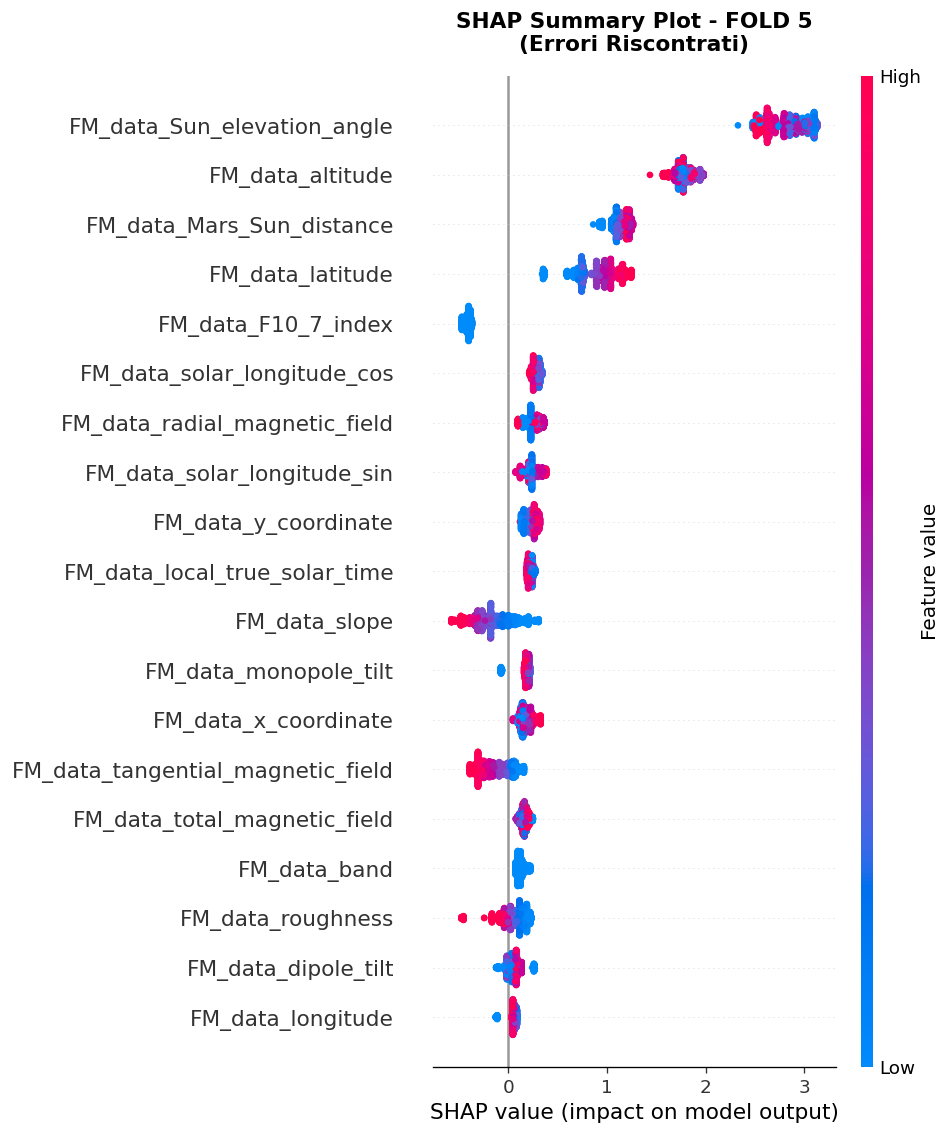

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import shap

from datetime import datetime

# Generiamo il timestamp unico e creiamo la cartella per i plot di SHAP
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("shap_plots", exist_ok=True)

# =====================================================================
# STEP 1: MACRO ANALYSIS - REGION COMPARISON (FOLD 1 vs FOLD 5)
# =====================================================================

print("\n--- 1A. Esecuzione SHAP su FOLD 1 (Zona Regolare - Performance Buone) ---")
model_fold1 = NeurNet(input_dim=input_dim_2)
weights_f1 = "experiments/exp_2_20260521_203007/model_exp_2_1.pth"
scaler_f1 = "experiments/exp_2_20260521_203007/scaler_chrono_exp_2_1.save"

shap_values_f1, X_test_scaled_f1, explainer_f1 = explain_with_shap(
    model=model_fold1,
    weights_path=weights_f1,
    scaler_path=scaler_f1,
    X_background_raw=X_train_fold1,  # Matrice grezza di train del Fold 1
    X_test_raw=X_test_fold1,          # Matrice grezza di test del Fold 1
    feature_names=feature_names_2,
    bg_limit=500,
    test_limit=2000
)

print("\n--- 1B. Esecuzione SHAP su FOLD 5 (Zona Problematica - Errore Elevato) ---")
model_fold5 = NeurNet(input_dim=input_dim_2)
weights_f5 = "experiments/exp_2_20260521_203007/model_exp_2_5.pth"
scaler_f5 = "experiments/exp_2_20260521_203007/scaler_chrono_exp_2_5.save"

shap_values_f5, X_test_scaled_f5, explainer_f5 = explain_with_shap(
    model=model_fold5,
    weights_path=weights_f5,
    scaler_path=scaler_f5,
    X_background_raw=X_train_fold5,  # Matrice grezza di train del Fold 5
    X_test_raw=X_test_fold5,          # Matrice grezza di test del Fold 5
    feature_names=feature_names_2,
    bg_limit=500,
    test_limit=2000
)

# 1. Generiamo la PRIMA immagine (Totalmente indipendente)
fig1 = plt.figure(figsize=(9, 5.5))
shap.summary_plot(shap_values_f1, X_test_scaled_f1, feature_names=feature_names_2, show=False)
plt.title("SHAP Summary Plot - FOLD 1\n(Performance Ottime)", fontsize=13, fontweight='bold', pad=15)

base_f1 = f"shap_plots/shap_summary_fold1_{timestamp}"
fig1.savefig(f"{base_f1}.png", dpi=600, bbox_inches='tight')
fig1.savefig(f"{base_f1}.pdf", format='pdf', bbox_inches='tight')

html_fold1 = fig_to_html_element(fig1)

# 2. Generiamo la SECONDA immagine (Totalmente indipendente)
fig2 = plt.figure(figsize=(9, 5.5))
shap.summary_plot(shap_values_f5, X_test_scaled_f5, feature_names=feature_names_2, show=False)
plt.title("SHAP Summary Plot - FOLD 5\n(Errori Riscontrati)", fontsize=13, fontweight='bold', pad=15)

base_f5 = f"shap_plots/shap_summary_fold5_{timestamp}"
fig2.savefig(f"{base_f5}.png", dpi=600, bbox_inches='tight')
fig2.savefig(f"{base_f5}.pdf", format='pdf', bbox_inches='tight')

html_fold5 = fig_to_html_element(fig2)


# 3. Affianchiamo le due immagini sulla stessa riga usando un container Flexbox
html_container = f"""
<div style="display: flex; justify-content: space-between; align-items: flex-start; width: 100%;">
    {html_fold1}
    {html_fold5}
</div>
"""

# Rendering finale nel notebook
display(HTML(html_container))

#### Micro analysis


--- 2. Estrazione e Analisi dei peggiori campioni del Fold 5 ---
Indici dei campioni più problematici nel Fold 5: [1663 1665 1664]
Errori assoluti corrispondenti: [13.4509449  13.34175682 13.29695511]

Generazione Waterfall Plot per il campione ad alto errore (Indice: 1663)...
   💾 Grafici salvati in: shap_single_plots/waterfall_fold5_sample_1663_20260523_164703 (.png/.pdf)


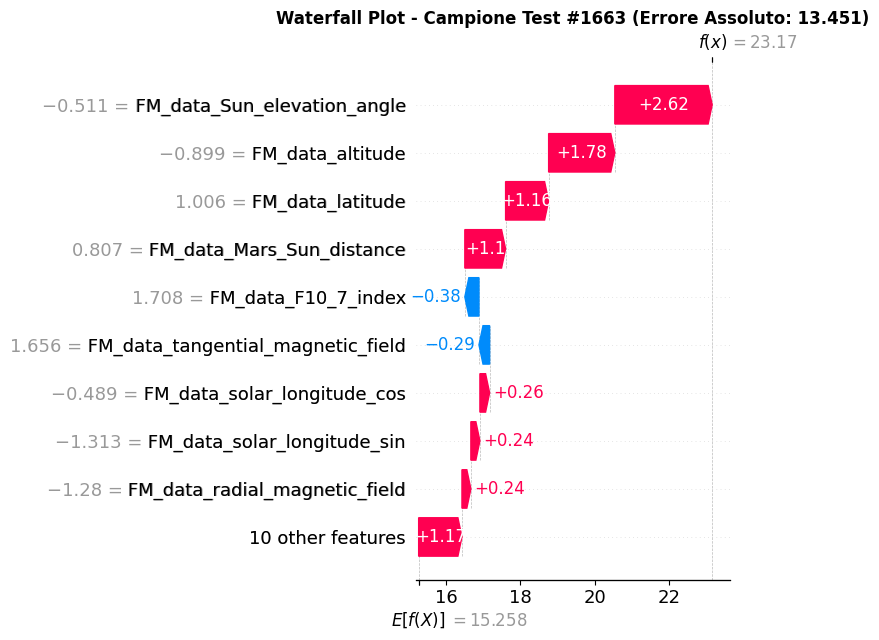


Generazione Waterfall Plot per il campione ad alto errore (Indice: 1665)...
   💾 Grafici salvati in: shap_single_plots/waterfall_fold5_sample_1665_20260523_164703 (.png/.pdf)


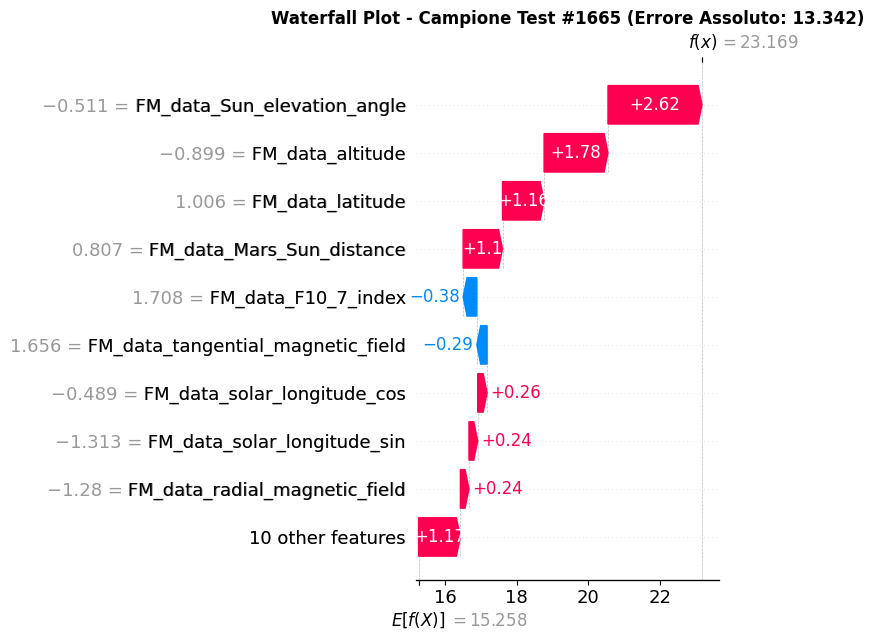


Generazione Waterfall Plot per il campione ad alto errore (Indice: 1664)...
   💾 Grafici salvati in: shap_single_plots/waterfall_fold5_sample_1664_20260523_164703 (.png/.pdf)


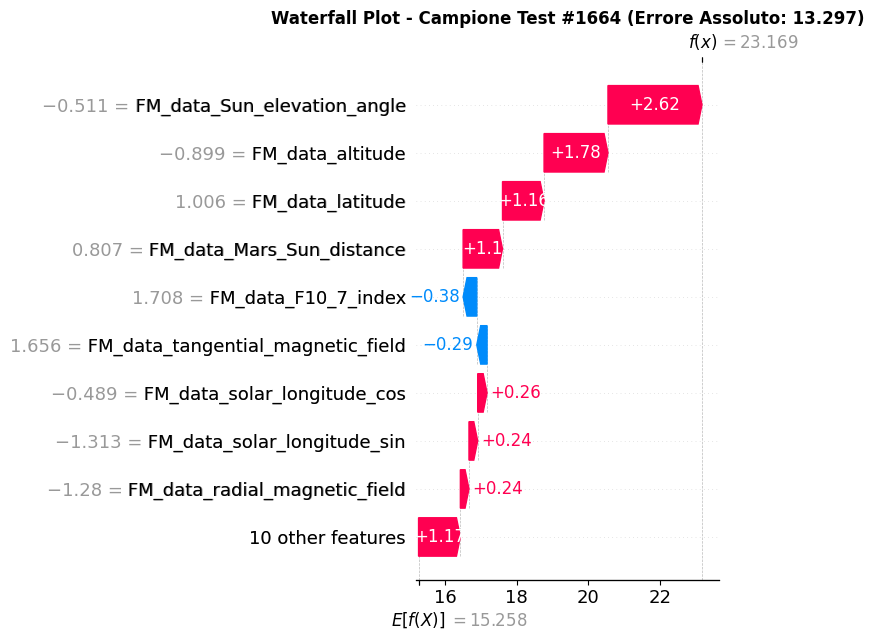

In [20]:
from datetime import datetime
import os

# Generiamo il timestamp unico per questa esecuzione e creiamo la cartella
timestamp_single = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("shap_single_plots", exist_ok=True)

# =====================================================================
# STEP 2: ANALISI MICROSCOPICA - ISOLAMENTO ANOMALIE & WATERFALL PLOT
# =====================================================================
print("\n--- 2. Estrazione e Analisi dei peggiori campioni del Fold 5 ---")

# Generazione delle predizioni del modello per calcolare l'errore reale residuo
model_fold5.to("cpu")
model_fold5.eval()
with torch.no_grad():
    # Convertiamo i dati di test già normalizzati in tensore pytorch
    tensor_test_f5 = torch.tensor(X_test_scaled_f5, dtype=torch.float32)
    # Calcolo output della rete e conversione in vettore numpy flat
    y_pred_f5 = model_fold5(tensor_test_f5).cpu().numpy().flatten()

# Calcolo del residuo assoluto su scala reale: Errore = |Y_predicton - Y_true|
# Assicurati che y_test_fold5 sia un array monodimensionale di numpy
limit = len(y_pred_f5)
absolute_errors = np.abs(y_pred_f5 - y_test_fold5[:limit].flatten())

# Estrazione degli indici dei 3 campioni con l'errore più alto (ordinamento crescente, prendi gli ultimi 3)
worst_samples_indices = np.argsort(absolute_errors)[-3:][::-1]

print(f"Indici dei campioni più problematici nel Fold 5: {worst_samples_indices}")
print(f"Errori assoluti corrispondenti: {absolute_errors[worst_samples_indices]}")

# Estrazione del valore atteso (E[f(x)]) di base dal DeepExplainer
base_value = explainer_f5.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[0]

# Generazione dei Waterfall Plot locali per ogni anomalia isolata
for idx in worst_samples_indices:
    print(f"\nGenerazione Waterfall Plot per il campione ad alto errore (Indice: {idx})...")
    
    # Chirurgia SHAP: impacchettiamo i vettori dentro un oggetto contenitore shap.Explanation
    explanation_object = shap.Explanation(
        values=shap_values_f5[idx], 
        base_values=base_value, 
        data=X_test_scaled_f5[idx], 
        feature_names=feature_names_2
    )
    
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(explanation_object, show=False)
    plt.title(f"Waterfall Plot - Campione Test #{idx} (Errore Assoluto: {absolute_errors[idx]:.3f})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    # --- CHIRURGIA DI SALVATAGGIO AD ALTA QUALITÀ ---
    # Includiamo 'idx' nel nome per evitare che i 3 grafici si sovrascrivano a vicenda
    base_name = f"shap_single_plots/waterfall_fold5_sample_{idx}_{timestamp_single}"
    plt.savefig(f"{base_name}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{base_name}.pdf", format='pdf', bbox_inches='tight')
    print(f"   💾 Grafici salvati in: {base_name} (.png/.pdf)")
    
    plt.show()

#### Investigating Fold 9


--- Estrazione Dati per il FOLD 9 ---
 🔹 FOLD 9 -> Train: (1715257, 19), Test: (190584, 19)

--- Esecuzione SHAP su FOLD 9 ---

=== STARTING SHAP PIPELINE ===
Model: experiments/exp_2_20260521_203007/model_exp_2_9.pth | Scaler: experiments/exp_2_20260521_203007/scaler_chrono_exp_2_9.save
Forced device for SHAP stability: cpu
SHAP calculation (Background: 500 samples, Test: 2000 samples)...
Generating plot...
SHAP calculation completed.
✅ Variabili shap_values_f9 e X_test_scaled_f9 generate con successo e pronte per il Dependence Plot!
✅ Variabili shap_values_f9 e X_test_scaled_f9 generate con successo!

--- 2. Analisi SHAP della singola feature (Flusso Solare) sul Fold 9 ---
Generazione dello SHAP Dependence Plot per 'FM_data_F10_7_index'...
    💾 Dependence Plot salvato.


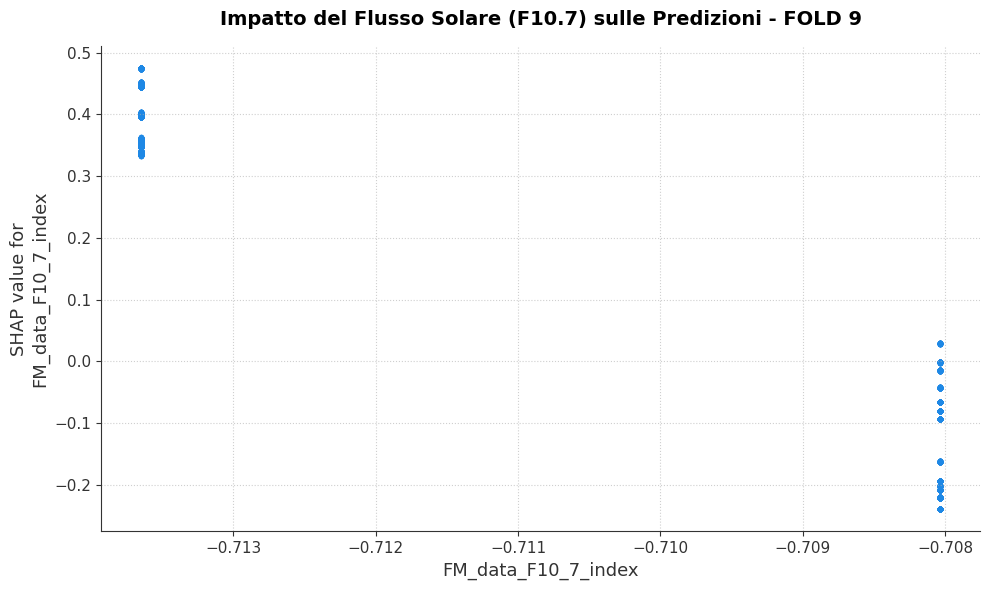


--- 2.5 Generazione Linea Continua (Output Modello vs Flusso Solare) ---
    💾 Grafico a linea continua salvato con successo.


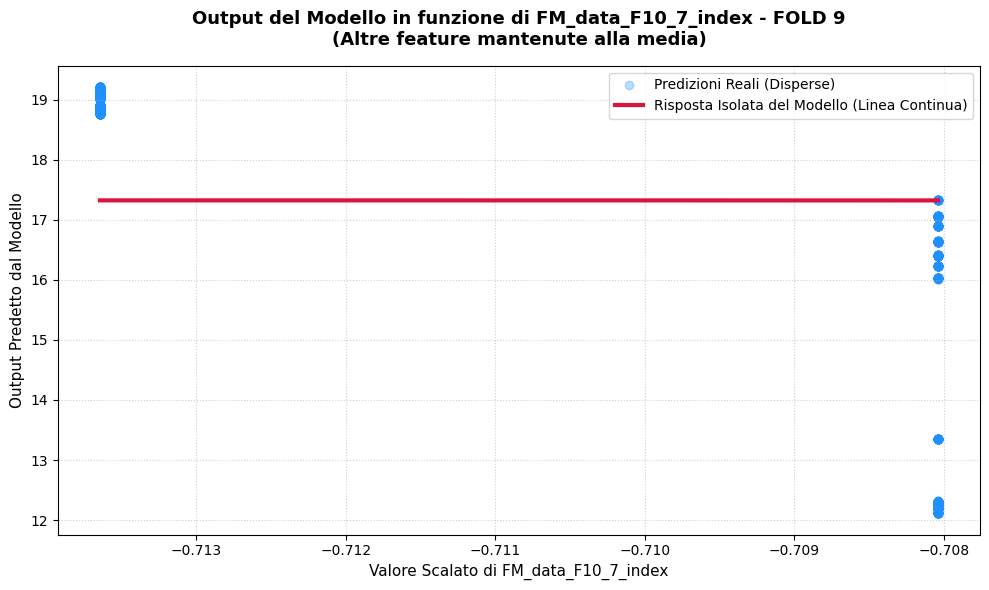


--- 3. Estrazione e Analisi dei peggiori campioni del Fold 9 (Waterfall) ---
Indici dei campioni più problematici nel Fold 9: [1812 1809 1886]
Errori assoluti corrispondenti: [7.72433853 7.01270294 6.87319183]
Generazione Waterfall Plot per il campione ad alto errore del Fold 9 (Indice: 1812)...
    💾 Grafico a cascata salvato in: shap_single_plots/waterfall_fold9_sample_1812_20260523_175625 (.png/.pdf)


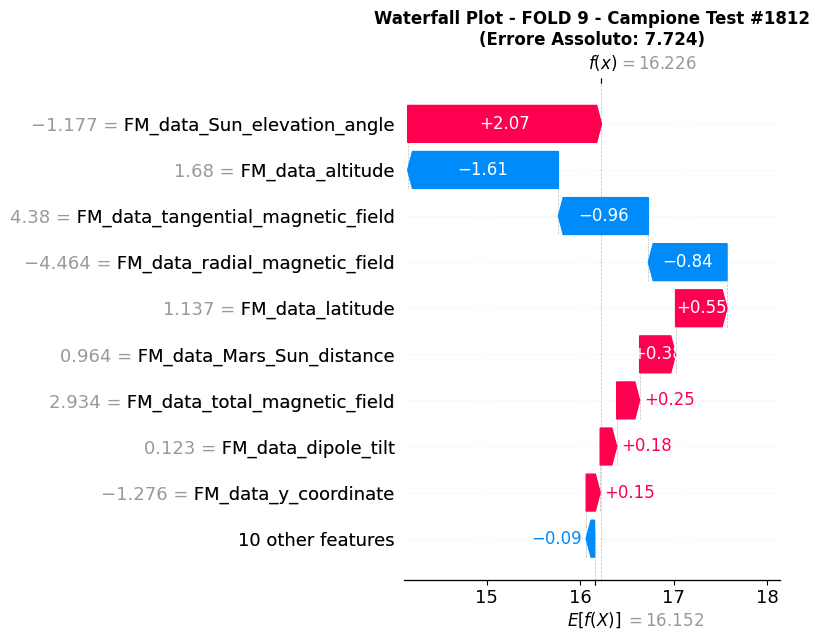

Generazione Waterfall Plot per il campione ad alto errore del Fold 9 (Indice: 1809)...
    💾 Grafico a cascata salvato in: shap_single_plots/waterfall_fold9_sample_1809_20260523_175625 (.png/.pdf)


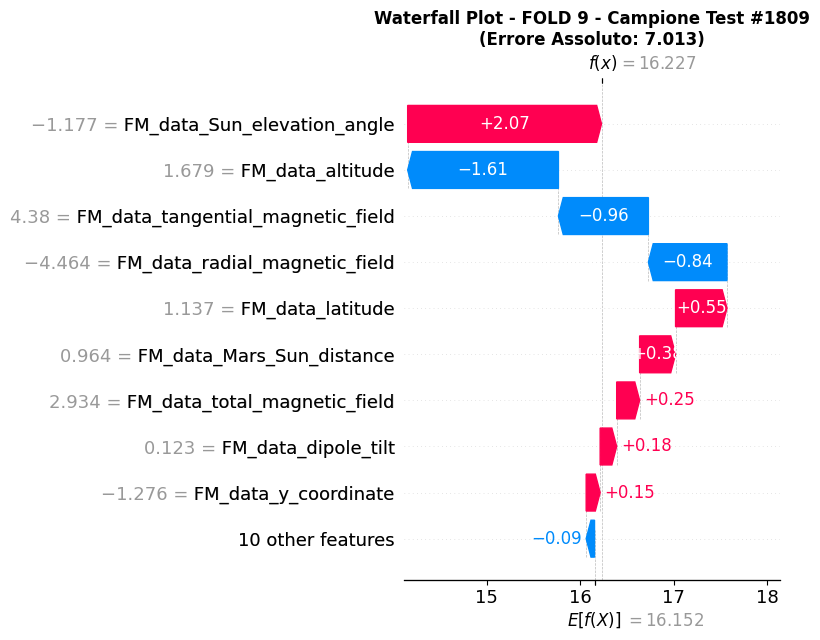

Generazione Waterfall Plot per il campione ad alto errore del Fold 9 (Indice: 1886)...
    💾 Grafico a cascata salvato in: shap_single_plots/waterfall_fold9_sample_1886_20260523_175625 (.png/.pdf)


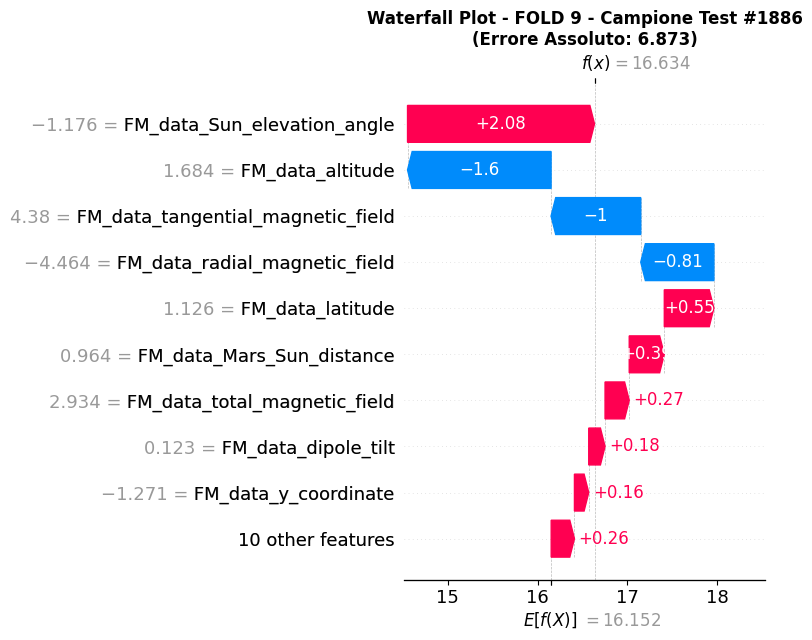

In [16]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import shap
from datetime import datetime
from shap_utils.explain_with_shap import *

# =====================================================================
# STEP 1.5: PREPARAZIONE ESTRAZIONE DATI E SHAP PER IL FOLD 9
# =====================================================================
print("\n--- Estrazione Dati per il FOLD 9 ---")

# 1. Ricostruzione delle matrici di Train e Test specifiche per il Fold 9
# (Assumendo che 'extracted_test_indices', 'X' e 'all_indices' siano già 
# disponibili in memoria dalle celle precedenti del tuo notebook)
test_idx_f9 = extracted_test_indices[9]
train_idx_f9 = np.setdiff1d(all_indices, test_idx_f9)

X_train_fold9 = X[train_idx_f9]
X_test_fold9  = X[test_idx_f9]
y_test_fold9 = y[test_idx_f9]

print(f" 🔹 FOLD 9 -> Train: {X_train_fold9.shape}, Test: {X_test_fold9.shape}")

print("\n--- Esecuzione SHAP su FOLD 9 ---")

# 2. Inizializzazione della rete
model_fold9 = NeurNet(input_dim=input_dim_2)

# 3. Path ai pesi e allo scaler del Fold 9 
# (Ho dedotto i nomi seguendo la logica dei tuoi path precedenti. 
# Verifica che il suffisso sia _9.pth e _9.save!)
weights_f9 = "experiments/exp_2_20260521_203007/model_exp_2_9.pth"
scaler_f9  = "experiments/exp_2_20260521_203007/scaler_chrono_exp_2_9.save"

# 4. Generazione degli SHAP values tramite la tua funzione di utility
shap_values_f9, X_test_scaled_f9, explainer_f9 = explain_with_shap(
    model=model_fold9,
    weights_path=weights_f9,
    scaler_path=scaler_f9,
    X_background_raw=X_train_fold9,  # La matrice grezza di train per il background
    X_test_raw=X_test_fold9,         # La matrice grezza di test da spiegare
    feature_names=feature_names_2,
    bg_limit=500,                    # Limite background (come nei fold precedenti)
    test_limit=2000                  # Limite test (come nei fold precedenti)
)

print("✅ Variabili shap_values_f9 e X_test_scaled_f9 generate con successo e pronte per il Dependence Plot!")

print("✅ Variabili shap_values_f9 e X_test_scaled_f9 generate con successo!")

# Generiamo il timestamp unico e creiamo la cartella dedicata
timestamp_single_9 = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("shap_single_plots", exist_ok=True)


# =====================================================================
# STEP 2: ANALISI MACROSCOPICA SINGOLA FEATURE - FOLD 9 (Flusso Solare)
# =====================================================================
print("\n--- 2. Analisi SHAP della singola feature (Flusso Solare) sul Fold 9 ---")

target_feature_9 = 'FM_data_F10_7_index'

if target_feature_9 not in feature_names_2:
    print(f"⚠️ Errore: La feature '{target_feature_9}' non è presente in feature_names_2.")
else:
    print(f"Generazione dello SHAP Dependence Plot per '{target_feature_9}'...")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    shap.dependence_plot(
        target_feature_9,
        shap_values_f9,          
        X_test_scaled_f9,        
        feature_names=feature_names_2,
        ax=ax,
        show=False,
        interaction_index=None   
    )
    
    plt.title(f"Impatto del Flusso Solare (F10.7) sulle Predizioni - FOLD 9", fontsize=14, fontweight='bold', pad=15)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    base_name_dep = f"shap_single_plots/dependence_fold9_solar_flux_{timestamp_single_9}"
    plt.savefig(f"{base_name_dep}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{base_name_dep}.pdf", format='pdf', bbox_inches='tight')
    print(f"    💾 Dependence Plot salvato.")
    plt.show()

# =====================================================================
# STEP 2.5: ANDAMENTO CONTINUO (PARTIAL DEPENDENCE) - FOLD 9
# =====================================================================
print("\n--- 2.5 Generazione Linea Continua (Output Modello vs Flusso Solare) ---")

# 1. Troviamo l'indice della colonna del Flusso Solare
target_idx = feature_names_2.index(target_feature_9)

# 2. Creiamo un "campione base" fissando tutte le altre feature alla loro media
X_mean_background = np.mean(X_test_scaled_f9, axis=0, keepdims=True)

# 3. Generiamo 100 punti perfettamente continui dal valore minimo al massimo
min_val = X_test_scaled_f9[:, target_idx].min()
max_val = X_test_scaled_f9[:, target_idx].max()
sweep_values = np.linspace(min_val, max_val, 100)

# 4. Creiamo 100 cloni del campione base e iniettiamo la nostra rampa continua di F10.7
X_synthetic = np.repeat(X_mean_background, 100, axis=0)
X_synthetic[:, target_idx] = sweep_values

# 5. Facciamo predire alla rete neurale questi 100 punti fittizi
model_fold9.to("cpu")
model_fold9.eval()
with torch.no_grad():
    tensor_synthetic = torch.tensor(X_synthetic, dtype=torch.float32)
    y_synthetic_pred = model_fold9(tensor_synthetic).cpu().numpy().flatten()
    
    # Calcoliamo anche le predizioni reali per tracciarle sullo sfondo
    tensor_real = torch.tensor(X_test_scaled_f9, dtype=torch.float32)
    y_real_pred = model_fold9(tensor_real).cpu().numpy().flatten()

# 6. Creazione del grafico con linea continua
fig, ax = plt.subplots(figsize=(10, 6))

# I punti reali in semitrasparenza (Output predetti vs Feature)
ax.scatter(X_test_scaled_f9[:, target_idx], y_real_pred, color='dodgerblue', alpha=0.3, label='Predizioni Reali (Disperse)')

# La linea continua del modello isolato
ax.plot(sweep_values, y_synthetic_pred, color='crimson', linewidth=3, label='Risposta Isolata del Modello (Linea Continua)')

plt.title(f"Output del Modello in funzione di {target_feature_9} - FOLD 9\n(Altre feature mantenute alla media)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel(f"Valore Scalato di {target_feature_9}", fontsize=11)
plt.ylabel("Output Predetto dal Modello", fontsize=11)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Salvataggio
base_name_line = f"shap_single_plots/continuous_line_fold9_solar_flux_{timestamp_single_9}"
plt.savefig(f"{base_name_line}.png", dpi=600, bbox_inches='tight')
plt.savefig(f"{base_name_line}.pdf", format='pdf', bbox_inches='tight')
print(f"    💾 Grafico a linea continua salvato con successo.")

plt.show()


# =====================================================================
# STEP 3: INNESTO CHIRURGICO - WATERFALL PLOT SUI PEGGIORI CAMPIONI (FOLD 9)
# =====================================================================
print("\n--- 3. Estrazione e Analisi dei peggiori campioni del Fold 9 (Waterfall) ---")

# 1. Generazione delle predizioni del modello per calcolare il residuo sul Fold 9
model_fold9.to("cpu")
model_fold9.eval()
with torch.no_grad():
    tensor_test_f9 = torch.tensor(X_test_scaled_f9, dtype=torch.float32)
    y_pred_f9 = model_fold9(tensor_test_f9).cpu().numpy().flatten()

# 2. Calcolo del residuo assoluto (Assicurati che y_test_fold9 sia estratto coerentemente come per gli altri fold)
# Se la variabile globale si chiama y_test_fold9, usiamo quella, altrimenti adattala (es: y_test_fold5)
limit_f9 = len(y_pred_f9)
absolute_errors_f9 = np.abs(y_pred_f9 - y_test_fold9[:limit_f9].flatten())

# 3. Estrazione degli indici dei 3 campioni con l'errore più alto nel Fold 9
worst_samples_f9 = np.argsort(absolute_errors_f9)[-3:][::-1]

print(f"Indici dei campioni più problematici nel Fold 9: {worst_samples_f9}")
print(f"Errori assoluti corrispondenti: {absolute_errors_f9[worst_samples_f9]}")

# 4. Estrazione del valore atteso di base dal DeepExplainer del Fold 9
base_value_f9 = explainer_f9.expected_value
if isinstance(base_value_f9, (list, np.ndarray)):
    base_value_f9 = base_value_f9[0]

# 5. Ciclo di generazione e salvataggio ad alta qualità per ogni anomalia del Fold 9
for idx in worst_samples_f9:
    print(f"Generazione Waterfall Plot per il campione ad alto errore del Fold 9 (Indice: {idx})...")
    
    explanation_object_f9 = shap.Explanation(
        values=shap_values_f9[idx], 
        base_values=base_value_f9, 
        data=X_test_scaled_f9[idx], 
        feature_names=feature_names_2
    )
    
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(explanation_object_f9, show=False)
    plt.title(f"Waterfall Plot - FOLD 9 - Campione Test #{idx}\n(Errore Assoluto: {absolute_errors_f9[idx]:.3f})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    # Salvataggio organizzato nella stessa cartella shap_single_plots
    base_name_water = f"shap_single_plots/waterfall_fold9_sample_{idx}_{timestamp_single_9}"
    plt.savefig(f"{base_name_water}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{base_name_water}.pdf", format='pdf', bbox_inches='tight')
    print(f"    💾 Grafico a cascata salvato in: {base_name_water} (.png/.pdf)")
    
    plt.show()

### Experiment 4: training neural network (batch size = 256) with lagged dataset

In [11]:
from utils.generate_lagged_dataset import *

In [12]:
import pandas as pd

# Carica un attimo il file solo per leggere le colonne
temp_df = pd.read_csv("Data/MARSIS_historical_dataset.csv", nrows=0)
print(temp_df.columns.tolist())

['FM_data_altitude;FM_data_band;FM_data_dipole_tilt;FM_data_ephemeris_time;FM_data_F10_7_index;FM_data_frequency;FM_data_latitude;FM_data_local_true_solar_time;FM_data_longitude;FM_data_Mars_Sun_distance;FM_data_median_corrected_echo_power;FM_data_monopole_tilt;FM_data_orbit_number;FM_data_peak_corrected_echo_power;FM_data_peak_distorted_echo_power;FM_data_peak_simulated_echo_power;FM_data_radial_magnetic_field;FM_data_roughness;FM_data_slope;FM_data_solar_longitude;FM_data_Sun_elevation_angle;FM_data_tangential_magnetic_field;FM_data_total_magnetic_field;FM_data_x_coordinate;FM_data_y_coordinate']


The code below moves the solar flux value back by one month.

In [13]:
df_1_month_lag = generate_lagged_dataset(
    input_csv_path="Data/MARSIS_historical_dataset.csv",
    output_csv_path="Data/MARSIS_historical_dataset_LAGGED_1M.csv",
    time_col="FM_data_ephemeris_time",
    feature_col="FM_data_F10_7_index",
    lag_months=1,
    drop_na=True
)

=== PREPARAZIONE DATASET CON LAG (FM_data_F10_7_index A -1 MESE/I) ===
⏱️ Rilevato tempo numerico (Ephemeris Time in secondi). Calcolo offset matematico...
Righe senza storico eliminate. Dimensione finale dataset: (4213548, 25)
✅ Nuovo dataset salvato con successo in: Data/MARSIS_historical_dataset_LAGGED_1M.csv



In [14]:
X_4, y_4, feature_names_4 = load_and_preprocess_data(dataset_path="Data/MARSIS_historical_dataset_LAGGED_1M.csv", orbit_path="Data/orbit_to_remove", keep_flux=True)

In [15]:
import pandas as pd

# 1. Controlliamo se X_4 e y_4 sono effettivamente vuoti
print(f"Dimensioni di X_4: {X_4.shape}")
print(f"Dimensioni di y_4: {y_4.shape}")

# 2. Controlliamo quante righe ha il CSV che stai leggendo
csv_path = "Data/MARSIS_historical_dataset_LAGGED_1M.csv" # Metti il path corretto se diverso
df_check = pd.read_csv(csv_path, sep=';')
print(f"\nRighe totali nel CSV: {len(df_check)}")

# 3. Controlliamo quante righe sopravvivono al filtro della frequenza
df_freq = df_check[df_check['FM_data_frequency'] == 4000000.0]
print(f"Righe dopo il filtro frequenza a 4MHz: {len(df_freq)}")

Dimensioni di X_4: (1896529, 19)
Dimensioni di y_4: (1896529,)

Righe totali nel CSV: 4213548
Righe dopo il filtro frequenza a 4MHz: 2074005


=== Starting Experiment Pipeline: exp_4 ===
Created isolated environment at: experiments/exp_4_20260524_160239

--- Starting FOLD 0 ---


Early stopping at epoch 31
Train MSE: 6.735, Test MSE: 12.416, Train MAE: 1.969, Test MAE: 2.627

--- Starting FOLD 1 ---


Early stopping at epoch 32
Train MSE: 6.484, Test MSE: 10.880, Train MAE: 1.905, Test MAE: 2.546

--- Starting FOLD 2 ---


Early stopping at epoch 16
Train MSE: 7.707, Test MSE: 9.913, Train MAE: 2.156, Test MAE: 2.485

--- Starting FOLD 3 ---


Early stopping at epoch 17
Train MSE: 7.328, Test MSE: 16.269, Train MAE: 2.078, Test MAE: 3.012

--- Starting FOLD 4 ---


...

Early stopping at epoch 13
Train MSE: 7.575, Test MSE: 51.073, Train MAE: 2.099, Test MAE: 5.391

--- Starting FOLD 6 ---


Early stopping at epoch 16
Train MSE: 7.212, Test MSE: 39.946, Train MAE: 2.053, Test MAE: 4.716

--- Starting FOLD 7 ---


Early stopping at epoch 21
Train MSE: 6.756, Test MSE: 26.966, Train MAE: 1.967, Test MAE: 3.653

--- Starting FOLD 8 ---


Early stopping at epoch 22
Train MSE: 7.273, Test MSE: 12.346, Train MAE: 2.074, Test MAE: 2.771

--- Starting FOLD 9 ---


Early stopping at epoch 12
Train MSE: 7.947, Test MSE: 11.341, Train MAE: 2.130, Test MAE: 2.621

Execution 'exp_4' successfully completed in 3277.20s!
Generating Learning Curves...


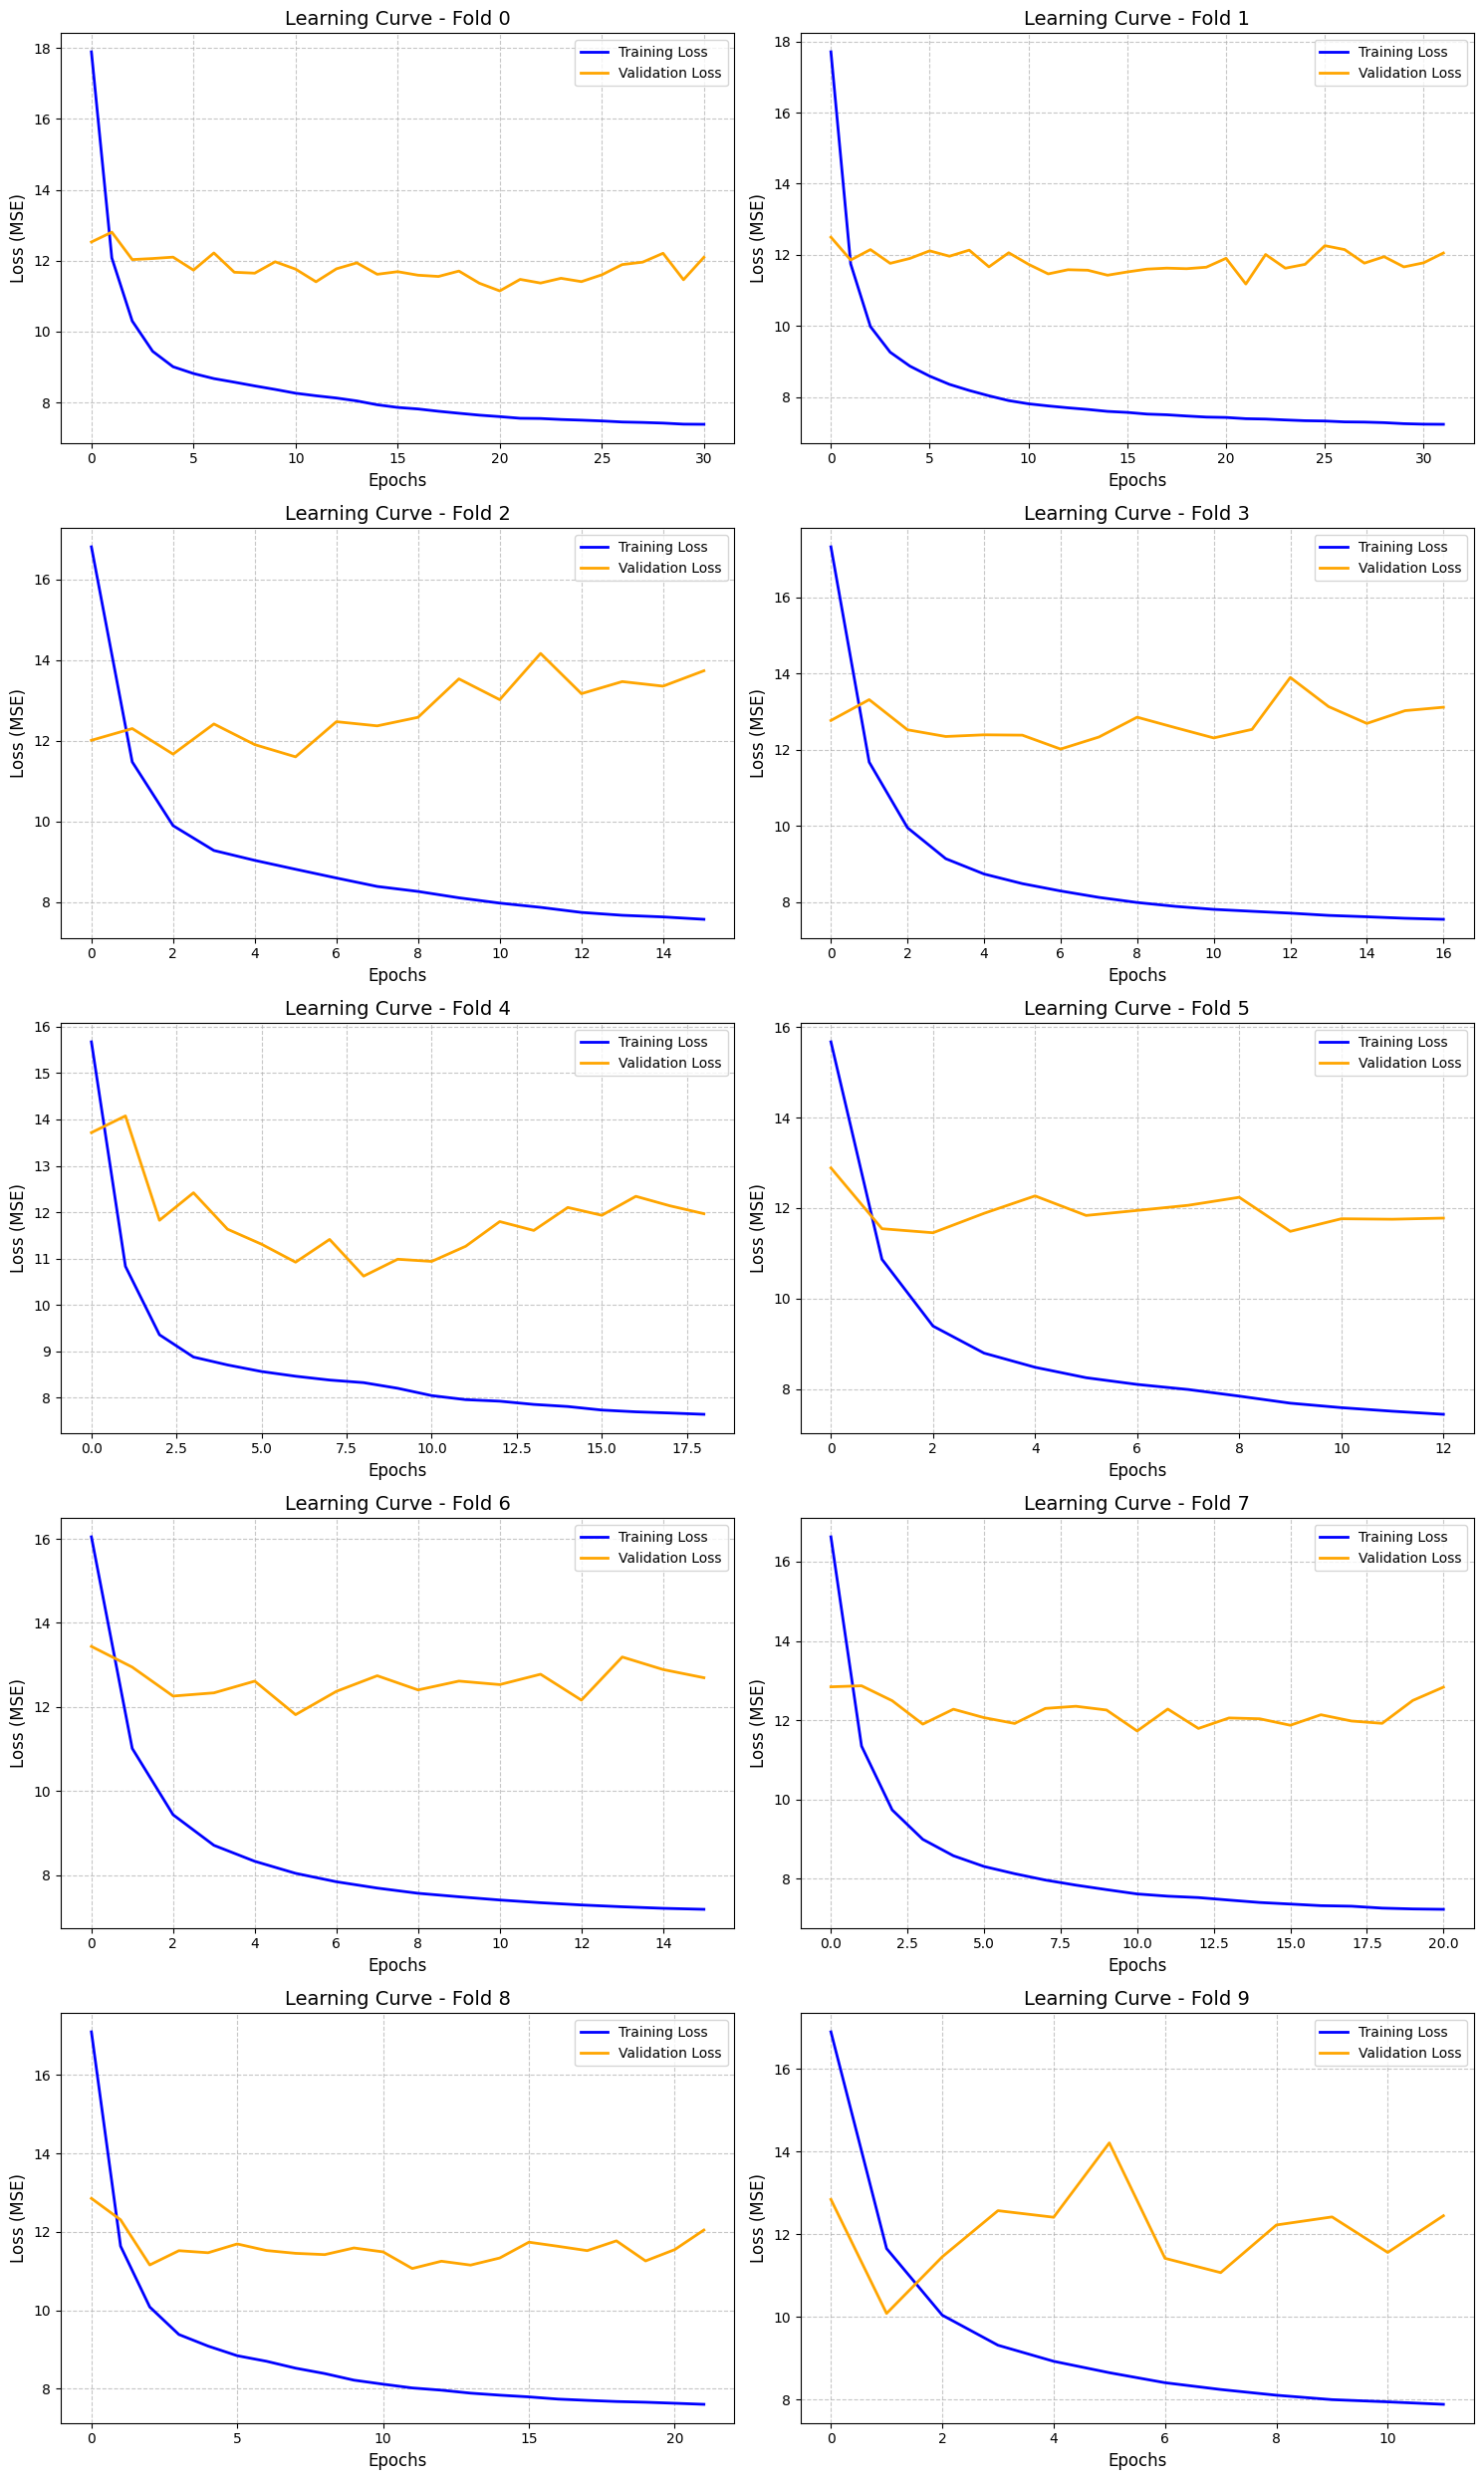

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/experiments/exp_4_20260524_160239


In [16]:
k_fold_dict_4, save_dir_4 = pipeline(X_4, y_4, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=256, exp_name="exp_4")

## Comparison between solar flux and folds

--- Generazione Grafico: Flusso Solare vs Divisione Fold ---
Grafico salvato con successo in: plots/solar_flux_folds_overlay_20260723_135943 (.png e .pdf)


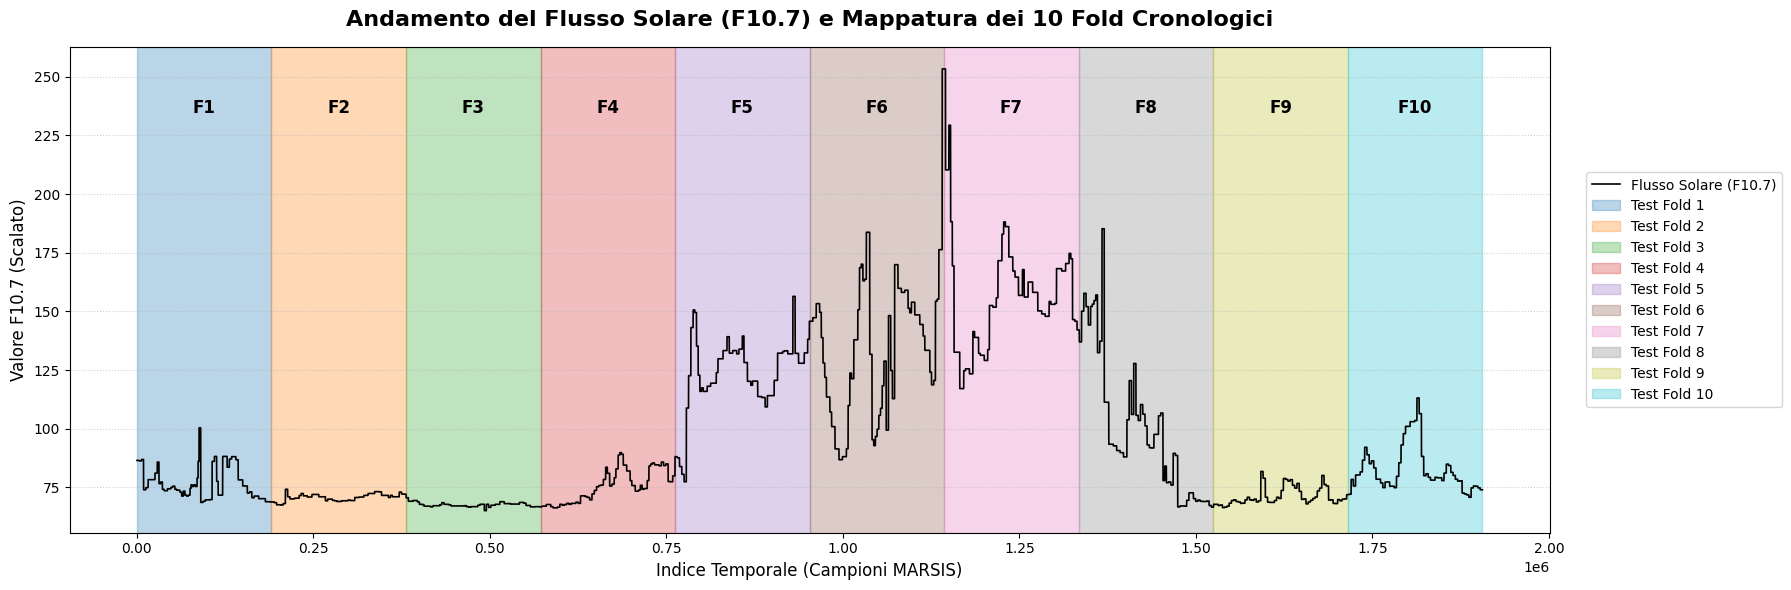

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold
from datetime import datetime
import os

print("--- Generazione Grafico: Flusso Solare vs Divisione Fold ---")

# Identificazione della colonna del Flusso Solare
target_feature = 'FM_data_F10_7_index'

if target_feature not in feature_names:
    raise ValueError(f"Feature '{target_feature}' non trovata nell'array feature_names.")

flux_idx = feature_names.index(target_feature)

# Estraiamo tutti i valori del flusso solare dalla matrice di addestramento
# Nota: Essendo estratti da X, i valori mostrati saranno quelli pre-processati/scalati
solar_flux_values = X[:, flux_idx]

# 2. Ricreazione esatta dei 10 Fold Cronologici usati nella pipeline
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=False) # shuffle=False mantiene l'ordine temporale

# 3. Configurazione della Figura
plt.figure(figsize=(18, 6))

# Disegniamo la linea continua del Flusso Solare in primo piano (zorder=2)
plt.plot(solar_flux_values, color='black', linewidth=1.2, label='Flusso Solare (F10.7)', zorder=2)

# 4. Creazione dell'overlay dei Fold
# Palette di colori per distinguere visivamente le 10 finestre di test
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

fold_idx = 1
for train_index, test_index in kf.split(X):
    # Troviamo l'inizio e la fine cronologica del Test Set per questo fold
    start_idx = test_index[0]
    end_idx = test_index[-1]
    
    # Aggiungiamo il rettangolo colorato di sfondo (zorder=1 per tenerlo dietro la linea)
    plt.axvspan(start_idx, end_idx, color=colors[(fold_idx-1) % len(colors)], 
                alpha=0.3, label=f'Test Fold {fold_idx}', zorder=1)
    
    # Aggiungiamo un'etichetta testuale in alto al centro di ogni fold
    mid_idx = (start_idx + end_idx) // 2
    plt.text(mid_idx, np.max(solar_flux_values) * 0.95, f'F{fold_idx}', 
             color='black', fontweight='bold', fontsize=12, ha='center', va='top', zorder=3)
    
    fold_idx += 1

# 5. Personalizzazione Grafica
plt.title('Andamento del Flusso Solare (F10.7) e Mappatura dei 10 Fold Cronologici', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Indice Temporale (Campioni MARSIS)', fontsize=12)
plt.ylabel('Valore F10.7 (Scalato)', fontsize=12)

# Griglia solo sull'asse Y per facilitare la lettura dei picchi
plt.grid(True, linestyle=':', alpha=0.6, axis='y')

# Spostiamo la legenda esternamente a destra per non coprire l'andamento della serie
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10)
plt.tight_layout()

# 6. Salvataggio su disco (coerente con la struttura delle cartelle del progetto)
timestamp_plot = datetime.now().strftime("%Y%m%d_%H%M%S")
save_path_plot = f"plots/solar_flux_folds_overlay_{timestamp_plot}"

plt.savefig(f"{save_path_plot}.png", dpi=600, bbox_inches='tight')
plt.savefig(f"{save_path_plot}.pdf", format='pdf', bbox_inches='tight')
print(f"Grafico salvato con successo in: {save_path_plot} (.png e .pdf)")

plt.show()